# Quantifying Rental Fair Value: Using Machine Learning and Geo-Cluster Features to Identify Local Market Differences and Rental Bargains


In [3]:
import os
import pandas as pd

base_path = os.path.abspath("../..")
data_path = os.path.join(base_path, "data", "apartments_for_rent_classified_100K.csv")

df_raw = pd.read_csv(
    data_path,
    sep=";",
    encoding="latin1",
    low_memory=False
)

df_raw.info()
df_raw.isnull().sum().sort_values(ascending=False).head(20)
df_raw.sample(5)
df_raw["price"].describe()
df_raw["price"].quantile([0.01, 0.05, 0.95, 0.99])
df_raw[df_raw["price"]>10000]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99492 entries, 0 to 99491
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             99492 non-null  int64  
 1   category       99492 non-null  object 
 2   title          99492 non-null  object 
 3   body           99492 non-null  object 
 4   amenities      83448 non-null  object 
 5   bathrooms      99429 non-null  float64
 6   bedrooms       99368 non-null  float64
 7   currency       99492 non-null  object 
 8   fee            99492 non-null  object 
 9   has_photo      99492 non-null  object 
 10  pets_allowed   39068 non-null  object 
 11  price          99491 non-null  float64
 12  price_display  99491 non-null  object 
 13  price_type     99492 non-null  object 
 14  square_feet    99492 non-null  int64  
 15  address        7943 non-null   object 
 16  cityname       99190 non-null  object 
 17  state          99190 non-null  object 
 18  latitu

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
537,5668636698,housing/rent/apartment,Two BR 1760 Avenida del Mundo Unit 508,This unit is located at 1760 Avenida del Mundo...,NaN,2.0,2.0,USD,No,Thumbnail,...,"$11,000",Monthly,1322,1760 Avenida Del Mundo Unit 508,Coronado,CA,32.6596,-117.1595,RentLingo,1577360129
3487,5668640983,housing/rent/apartment,Six BR 256 Las Entradas,"This unit is located at 256 Las Entradas, Mont...",NaN,8.0,6.0,USD,No,Thumbnail,...,"$25,000",Monthly,8716,256 Las Entradas,Montecito,CA,34.4331,-119.6331,RentLingo,1577360419
3907,5668643292,housing/rent/apartment,Six BR 9908 Bentcross Drive,"This unit is located at 9908 Bentcross Drive, ...",NaN,8.5,6.0,USD,No,Thumbnail,...,"$11,000",Monthly,11318,9908 Bentcross Dr,Potomac,MD,39.0287,-77.2409,RentLingo,1577360560
5222,5664581587,housing/rent/apartment,Six BR 3033 N Beverly Glen Cir,This unit is located at 3033 N Beverly Glen Ci...,NaN,4.0,6.0,USD,No,Thumbnail,...,"$14,950",Monthly,4044,3033 N Beverly Glen Circle,Los Angeles,CA,34.0372,-118.2972,RentLingo,1577015930
6574,5659901599,housing/rent/apartment,Four BR 864 Teakwood Rd,"This unit is located at 864 Teakwood Rd, Los A...","Dishwasher,Parking,Pool,Refrigerator",5.0,4.0,USD,No,Thumbnail,...,"$19,500",Monthly,5000,864 Teakwood Road,Los Angeles,CA,34.0372,-118.2972,RentLingo,1576666648
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93975,5122325289,housing/rent/apartment,Convenient location Three BR 2.50 BA for rent....,"Square footage: 2591 sq. feet, unit number: 17...",Parking,2.5,3.0,USD,No,Yes,...,"$10,379",Monthly,2591,NaN,Nashville,TN,36.0960,-86.8262,RentDigs.com,1544275278
95244,5122012570,housing/rent/apartment,luxurious Four Seasons. Parking Available!,Amazing location. A wonderful opportunity to l...,Parking,5.0,4.0,USD,No,Yes,...,"$19,500",Monthly,4380,NaN,San Francisco,CA,37.7740,-122.4104,RentDigs.com,1544250657
95774,5121433095,housing/rent/apartment,Bedford - superb Apartment nearby fine dining,Enter private gates to a four plus acre TOTALL...,"AC,Cable or Satellite,Dishwasher,Fireplace,Gym...",6.0,5.0,USD,No,Yes,...,"$11,500",Monthly,8643,NaN,Bedford,NY,41.1852,-73.6409,RentDigs.com,1544202710
95926,5121048460,housing/rent/apartment,Two BR Apartment - In one of the most sought a...,Apartment 3R in the Chelsea Mercantile is the ...,"Doorman,Gym,Parking,Patio/Deck,Storage,Washer ...",2.0,2.0,USD,No,Yes,...,"$11,250",Monthly,2269,NaN,New York,NY,40.7247,-73.9545,RentDigs.com,1544174637


In [4]:
(df_raw["price"] == 0).sum()

0

In [5]:
df_raw[df_raw["price"] == 0].head(10)

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time


# 1. Data Cleaning and Preprocessing

In [6]:
import os
import pandas as pd
import numpy as np

# =========================
# 1. Load data
# =========================
base_path = os.path.abspath("../..")
data_path = os.path.join(base_path, "data", "apartments_for_rent_classified_100K.csv")

df = pd.read_csv(
    data_path,
    sep=";",
    encoding="latin1",
    low_memory=False
)

print("Original shape:", df.shape)

# =========================
# 2. Standardize missing values
# =========================
df = df.replace(["null", "NULL", "", " "], np.nan)

# =========================
# 3. Drop duplicates
# =========================
df = df.drop_duplicates()
df = df.drop_duplicates(subset=["id"])

# =========================
# 4. Standardize text fields
# =========================
df["price_type"] = df["price_type"].astype(str).str.strip().str.lower()
df["category"] = df["category"].astype(str).str.strip().str.lower()
df["state"] = df["state"].astype("string")
df["cityname"] = df["cityname"].astype("string")

# Keep apartment listings only
df = df[df["category"] == "housing/rent/apartment"]

# =========================
# 5. Convert numeric columns
# =========================
numeric_cols = ["price", "bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# =========================
# 6. Standardize price to monthly
# =========================
df = df[df["price_type"].isin(["monthly", "weekly"])]

df["price_monthly"] = np.where(
    df["price_type"] == "weekly",
    df["price"] * (52 / 12),
    df["price"]
)

# Drop missing target
df = df.dropna(subset=["price_monthly"])

# =========================
# 7. Remove unreasonable values
# =========================
df = df[(df["price_monthly"] > 0) & (df["price_monthly"] < 10000)]
df = df[(df["bathrooms"].isna()) | ((df["bathrooms"] > 0) & (df["bathrooms"] < 10))]
df = df[(df["bedrooms"].isna()) | ((df["bedrooms"] >= 0) & (df["bedrooms"] < 10))]
df = df[(df["square_feet"].isna()) | ((df["square_feet"] > 100) & (df["square_feet"] < 10000))]

# =========================
# 8. Clean location fields
# =========================
df["state"] = df["state"].fillna("Unknown").str.strip()
df["cityname"] = df["cityname"].fillna("Unknown").str.strip()

# Only lat/lon are required for spatial analysis
df = df.dropna(subset=["latitude", "longitude"])

df["lat"] = df["latitude"]
df["lon"] = df["longitude"]

# =========================
# 9. Clean text columns
# =========================
df["pets_allowed"] = df["pets_allowed"].fillna("No Info").str.strip().str.lower()
df["amenities_clean"] = df["amenities"].fillna("").str.lower()
df["has_photo"] = df["has_photo"].fillna("no").astype(str).str.strip().str.lower()

# =========================
# 10. Pet features
# =========================
df["pet_cat"] = df["pets_allowed"].str.contains("cat", regex=False).astype(int)
df["pet_dog"] = df["pets_allowed"].str.contains("dog", regex=False).astype(int)
df["pet_any"] = ((df["pet_cat"] == 1) | (df["pet_dog"] == 1)).astype(int)

# =========================
# 11. Amenity features
# =========================
key_amenities = ["parking", "pool", "gym", "dishwasher", "elevator", "washer", "dryer"]

for item in key_amenities:
    df[f"amenity_{item}"] = df["amenities_clean"].str.contains(item, regex=False).astype(int)

df["has_amenities"] = df["amenities"].notna().astype(int)

# =========================
# 12. Time conversion
# =========================
df["time"] = pd.to_datetime(df["time"], unit="s", errors="coerce")
df["month"] = df["time"].dt.month
df["year"] = df["time"].dt.year

# =========================
# 13. Log target for modeling
# =========================
df["log_price"] = np.log1p(df["price_monthly"])

# =========================
# 14. Final quick check
# =========================
print("Cleaned shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))

print("\nPrice summary:")
print(df["price_monthly"].describe())

print("\nSample columns:")
print(df[[
    "price_monthly", "log_price", "bedrooms", "bathrooms", "square_feet",
    "state", "cityname", "lat", "lon", "pet_any"
] + [f"amenity_{a}" for a in key_amenities]].head())
df.shape
df.isnull().sum().sort_values(ascending=False).head(20)

Original shape: (99492, 22)
Cleaned shape: (99237, 40)

Missing values:
address               91308
amenities             16011
bedrooms                122
bathrooms                58
id                        0
amenity_pool              0
lon                       0
amenities_clean           0
pet_cat                   0
pet_dog                   0
pet_any                   0
amenity_parking           0
amenity_dishwasher        0
amenity_gym               0
price_monthly             0
amenity_elevator          0
amenity_washer            0
amenity_dryer             0
has_amenities             0
month                     0
dtype: int64

Price summary:
count    99237.000000
mean      1514.828434
std        758.314739
min        100.000000
25%       1012.000000
50%       1350.000000
75%       1795.000000
max       9975.000000
Name: price_monthly, dtype: float64

Sample columns:
   price_monthly  log_price  bedrooms  bathrooms  square_feet state  \
0         2195.0   7.694393       1.0  

address               91308
amenities             16011
bedrooms                122
bathrooms                58
id                        0
amenity_pool              0
lon                       0
amenities_clean           0
pet_cat                   0
pet_dog                   0
pet_any                   0
amenity_parking           0
amenity_dishwasher        0
amenity_gym               0
price_monthly             0
amenity_elevator          0
amenity_washer            0
amenity_dryer             0
has_amenities             0
month                     0
dtype: int64

Raw Data Shape

The raw dataset has **99,492 rows and 22 columns**.

After cleaning, the dataset has **99,237 rows and 40 columns**.

This means only a small number of rows were removed, while more variables were created during preprocessing and feature engineering.

In [7]:
print("df_raw shape:", df_raw.shape)
print("df shape:", df.shape)
df_raw["price_type"].value_counts()
print(df_raw.shape[0])
print(df_raw["id"].nunique())
print(df_raw["id"].duplicated().sum())
df_raw["body"].astype(str).str.contains("\n", regex=False).sum()
rows_with_newline = df_raw[df_raw["body"].astype(str).str.contains("\n", regex=False)]
rows_with_newline[["id", "body"]].head(3)
print("rows:", df_raw.shape[0])
print("unique ids:", df_raw["id"].nunique())
print("duplicate ids:", df_raw["id"].duplicated().sum())
print("body contains newline:", df_raw["body"].astype(str).str.contains("\n", regex=False).sum())

df_raw shape: (99492, 22)
df shape: (99237, 40)
99492
99408
84
rows: 99492
unique ids: 99408
duplicate ids: 84
body contains newline: 7


Duplicate Check

The raw dataset contains **99,492 rows** but only **99,408 unique IDs**, which means there are **84 duplicate IDs**.

This shows that a small number of duplicate listings exist in the raw data and need to be handled during cleaning.

In [8]:
for col in ["currency", "fee", "price_type", "source", "has_photo", "state"]:
    print("\n", col)
    print(df_raw[col].value_counts(dropna=False).head(10))


 currency
currency
USD    99492
Name: count, dtype: int64

 fee
fee
No     99291
Yes      201
Name: count, dtype: int64

 price_type
price_type
Monthly           99488
Weekly                3
Monthly|Weekly        1
Name: count, dtype: int64

 source
source
RentDigs.com        90912
RentLingo            6924
ListedBuy             571
GoSection8            437
RealRentals           268
tenantcloud           124
BostonApartments       94
RENTCafé               41
Listanza               29
SpreadMyAd             22
Name: count, dtype: int64

 has_photo
has_photo
Yes          55974
Thumbnail    34303
No            9215
Name: count, dtype: int64

 state
state
TX    11257
CA    10311
VA     8284
NC     6300
CO     6290
FL     5775
MD     5280
MA     5030
OH     4905
GA     4752
Name: count, dtype: int64


Basic Variable Inspection

Some fields are highly consistent in the raw data:

- `currency` is always **USD**
- `fee` is mostly **No**
- `price_type` is almost entirely **Monthly**

This suggests that the dataset is already relatively consistent in pricing format, although a small number of non-monthly records still need to be standardized.

In [9]:
missing = df_raw.isnull().mean().sort_values(ascending=False) * 100
print(missing.head(10))

address         92.016444
pets_allowed    60.732521
amenities       16.125920
state            0.303542
cityname         0.303542
bedrooms         0.124633
bathrooms        0.063322
longitude        0.025128
latitude         0.025128
price            0.001005
dtype: float64


Missing Values Before Cleaning

The missing value check shows that several variables have incomplete records.

The most serious missing field is `address`, with more than **91,000** missing values.  
Other variables with noticeable missingness include:

- `pets_allowed`
- `amenities`
- `state`
- `cityname`
- `bedrooms`
- `bathrooms`
- `longitude`
- `latitude`
- `price`

This indicates that the raw dataset requires cleaning before modeling.

In [10]:
print(df_raw["id"].nunique())
print(df_raw.shape[0])

99408
99492


In [11]:
df_raw[["title", "body", "amenities", "pets_allowed"]].sample(5)

,title,body,amenities,pets_allowed
57551,"Apartment only for $3,710/mo. You Can Stop Loo...","Square footage: 1280 square ft, unit number: 1...",NaN,"Cats,Dogs"
9456,Over 700 sf in Kent,"Square footage: 700 sq. feet, unit number: 2C-...",NaN,NaN
45679,This rental is a Sammamish apartment located S...,Square footage: 904 sq-ft The property feature...,NaN,NaN
88127,"Move-in condition, Three BR Two BA",Bridges Apartment Homes is a unique apartment ...,"AC,Clubhouse,Gym,Parking,Patio/Deck,Playground...","Cats,Dogs"
64346,Two BR Apartment - Camden Montague has unique ...,"Square footage: 1096 sq. feet, unit number: 20...","Gated,Gym,Internet Access,Parking,Pool,TV,Wash...",NaN


Missing Values After Cleaning

After cleaning, missing values are reduced in several key fields.

The main remaining missing variables are:

- `address`
- `amenities`
- `bedrooms`
- `bathrooms`

At the same time, engineered variables such as amenity indicators, pet indicators, `price_monthly`, `lon`, `amenities_clean`, and `month` no longer have missing values.

This shows that the preprocessing step successfully converts several raw fields into more usable structured features.

In [12]:

df_raw["amenities"].isnull().mean()


0.16125919671933422

In [13]:
df_raw["amenities"].dropna().str.split(",").apply(len).describe()

count    83448.000000
mean         4.367498
std          3.151179
min          1.000000
25%          2.000000
50%          3.000000
75%          6.000000
max         18.000000
Name: amenities, dtype: float64

               price_monthly  square_feet  bedrooms  bathrooms
price_monthly       1.000000     0.383893  0.241117   0.321004
square_feet         0.383893     1.000000  0.710257   0.715240
bedrooms            0.241117     0.710257  1.000000   0.678410
bathrooms           0.321004     0.715240  0.678410   1.000000


<Axes: xlabel='bedrooms', ylabel='price_monthly'>

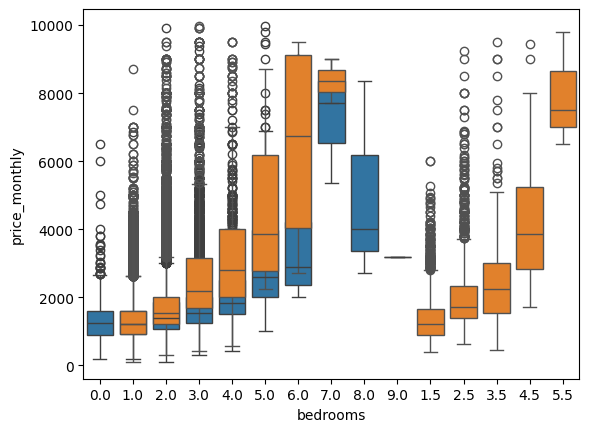

In [14]:
import seaborn as sns

corr = df[["price_monthly", "square_feet", "bedrooms", "bathrooms"]].corr()
print(corr)
sns.boxplot(x=df["bedrooms"], y=df["price_monthly"])
sns.boxplot(x=df["bathrooms"], y=df["price_monthly"])

In [15]:
for col in df_raw.columns:
    print("\n" + "="*50)
    print("Column:", col)
    print("Dtype:", df_raw[col].dtype)
    print("Missing:", df_raw[col].isnull().sum(), 
          f"({df_raw[col].isnull().mean()*100:.2f}%)")
    print("Unique:", df_raw[col].nunique(dropna=False))
    
    if df_raw[col].dtype == "object":
        print(df_raw[col].value_counts(dropna=False).head(10))
    else:
        print(df_raw[col].describe())


Column: id
Dtype: int64
Missing: 0 (0.00%)
Unique: 99408
count    9.949200e+04
mean     5.358321e+09
std      1.847404e+08
min      5.121046e+09
25%      5.197950e+09
50%      5.508673e+09
75%      5.509007e+09
max      5.669439e+09
Name: id, dtype: float64

Column: category
Dtype: object
Missing: 0 (0.00%)
Unique: 7
category
housing/rent/apartment            99431
housing/rent/commercial/retail       42
housing/rent                          7
housing/rent/home                     4
housing/rent/short_term               4
housing/rent/condo                    3
housing/rent/other                    1
Name: count, dtype: int64

Column: title
Dtype: object
Missing: 0 (0.00%)
Unique: 58503
title
Apartment in great location                            1064
Apartment in prime location                            1028
Apartment in quiet area, spacious with big kitchen     1023
Super Cute! Apartment for Rent!                        1018
This Apartment is a must see!                          10

Category Filtering

The original `category` field contains several listing types, including:

- `housing/rent/apartment`
- `housing/rent/commercial/retail`
- `housing/rent`
- `housing/rent/home`
- `housing/rent/short_term`

After cleaning, only `housing/rent/apartment` is kept.

This makes the final dataset more consistent for apartment rent analysis.

In [16]:
print("Rows before:", df_raw.shape[0])
print("Rows after:", df.shape[0])
print("Columns before:", df_raw.shape[1])
print("Columns after:", df.shape[1])
print("\nMissing BEFORE:")
print(df_raw.isnull().sum().sort_values(ascending=False).head(10))

print("\nMissing AFTER:")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nPrice BEFORE:")
print(df_raw["price"].describe())

print("\nPrice AFTER:")
print(df["price_monthly"].describe())
print(df_raw["category"].value_counts().head())
print(df["category"].value_counts().head())

Rows before: 99492
Rows after: 99237
Columns before: 22
Columns after: 40

Missing BEFORE:
address         91549
pets_allowed    60424
amenities       16044
state             302
cityname          302
bedrooms          124
bathrooms          63
longitude          25
latitude           25
price               1
dtype: int64

Missing AFTER:
address            91308
amenities          16011
bedrooms             122
bathrooms             58
id                     0
amenity_pool           0
lon                    0
amenities_clean        0
pet_cat                0
pet_dog                0
dtype: int64

Price BEFORE:
count    99491.000000
mean      1527.057281
std        904.245882
min        100.000000
25%       1013.000000
50%       1350.000000
75%       1795.000000
max      52500.000000
Name: price, dtype: float64

Price AFTER:
count    99237.000000
mean      1514.828434
std        758.314739
min        100.000000
25%       1012.000000
50%       1350.000000
75%       1795.000000
max       

Price Summary Before and After Cleaning

Before cleaning:

- mean price = **1527.06**
- std = **904.25**
- max = **52,500**

After cleaning:

- mean monthly price = **1514.83**
- std = **758.31**
- max = **9,975**

The average price changes only slightly, but the standard deviation and maximum value decrease clearly after cleaning. This suggests that extreme price values were reduced while the overall price level remained stable.

Amenity Processing

The `amenities` field has missing values, but for non-missing records it still contains useful information.

The descriptive statistics of the number of amenities show:

- count = **83,448**
- mean = **4.37**
- median = **3**
- max = **18**

This suggests that amenity information is available for a large number of listings and can be transformed into structured features.

Sample of Engineered Variables

After cleaning, the dataset includes newly prepared variables such as:

- `price_monthly`
- `log_price`
- `pet_any`
- `amenity_parking`
- `amenity_pool`
- `amenity_gym`
- `amenity_dishwasher`
- `amenity_elevator`
- `amenity_washer`
- `amenity_dryer`

These variables make the dataset more suitable for later analysis and modeling.


Summary

Overall, the cleaning process changes the dataset from **99,492 × 22** to **99,237 × 40**.

The main results of this step are:

- duplicate records were checked
- only apartment listings were retained
- monthly rent was prepared as a consistent target variable
- several structured features were created from pets and amenities
- extreme price values were reduced
- the cleaned dataset became more suitable for further analysis

# 2. Exploratory Data Analysis

## 2.1 Overall target understanding

In [17]:
# Overall understanding of data
print(df.shape)
print(df.info())

# miss rate
missing = df.isnull().mean().sort_values(ascending=False)
print(missing.head(10))

# View the sample
df.sample(5)

(99237, 40)
<class 'pandas.core.frame.DataFrame'>
Index: 99237 entries, 0 to 99491
Data columns (total 40 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  99237 non-null  int64         
 1   category            99237 non-null  object        
 2   title               99237 non-null  object        
 3   body                99237 non-null  object        
 4   amenities           83226 non-null  object        
 5   bathrooms           99179 non-null  float64       
 6   bedrooms            99115 non-null  float64       
 7   currency            99237 non-null  object        
 8   fee                 99237 non-null  object        
 9   has_photo           99237 non-null  object        
 10  pets_allowed        99237 non-null  object        
 11  price               99237 non-null  float64       
 12  price_display       99237 non-null  object        
 13  price_type          99237 non-null  obj

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,amenity_pool,amenity_gym,amenity_dishwasher,amenity_elevator,amenity_washer,amenity_dryer,has_amenities,month,year,log_price
68709,5198459633,housing/rent/apartment,"Apartment only for $1,623/mo. You Can Stop Loo...","Creek brings you state of the art amenities, s...","Fireplace,Gym,Pool",2.0,2.0,USD,No,no,...,1,1,0,0,0,0,1,2,2019,7.392648
51869,5215265395,housing/rent/apartment,Newly renovated First floor One BR apartment f...,East Windsor (Hightstown) Nice first level one...,"AC,Cable or Satellite,Internet Access,Patio/De...",1.0,1.0,USD,No,thumbnail,...,1,0,0,0,0,0,1,3,2019,7.131699
36969,5508854881,housing/rent/apartment,Apartment in move in condition in East Weymouth,Square footage: 870 sq-ft Living rooms are spa...,"Dishwasher,Gym,Parking,Patio/Deck,Playground,P...",1.5,2.0,USD,No,no,...,1,1,1,0,1,0,1,9,2019,7.467942
78486,5198260885,housing/rent/apartment,Apartment in great location,24/7 fitness facilities - 17 in monitors on al...,"Gym,Parking,Pool",1.0,1.0,USD,No,thumbnail,...,1,1,0,0,0,0,1,2,2019,7.189922
1022,5668615259,housing/rent/apartment,Two BR 3200 Shrine Park Rd,"This unit is located at 3200 Shrine Park Rd, L...","Cable or Satellite,Clubhouse,Dishwasher,Garbag...",2.0,2.0,USD,No,thumbnail,...,1,0,1,0,1,0,1,12,2019,6.716595


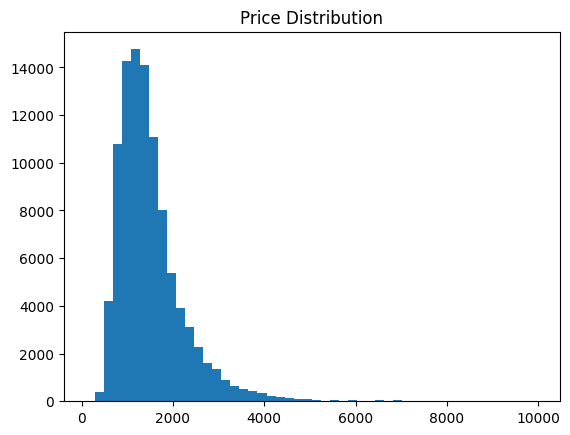

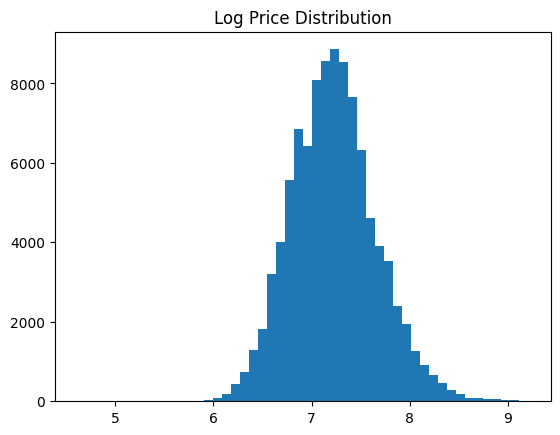

count    99237.000000
mean      1514.828434
std        758.314739
min        100.000000
25%       1012.000000
50%       1350.000000
75%       1795.000000
max       9975.000000
Name: price_monthly, dtype: float64


In [18]:
#Target(price) analysis
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.hist(df["price_monthly"], bins=50)
plt.title("Price Distribution")
plt.show()

plt.figure()
plt.hist(df["log_price"], bins=50)
plt.title("Log Price Distribution")
plt.show()

print(df["price_monthly"].describe())

In [19]:
from scipy.stats import skew

print("Original price skew:", skew(df["price_monthly"]))
print("Log price skew:", skew(df["log_price"]))

Original price skew: 2.4349124022139668
Log price skew: 0.31718162554178203


In [20]:
corr_raw = df[["price_monthly", "square_feet", "bedrooms", "bathrooms"]].corr()
corr_log = df[["log_price", "square_feet", "bedrooms", "bathrooms"]].corr()

print("Raw correlation:\n", corr_raw)
print("\nLog correlation:\n", corr_log)

Raw correlation:
                price_monthly  square_feet  bedrooms  bathrooms
price_monthly       1.000000     0.383893  0.241117   0.321004
square_feet         0.383893     1.000000  0.710257   0.715240
bedrooms            0.241117     0.710257  1.000000   0.678410
bathrooms           0.321004     0.715240  0.678410   1.000000

Log correlation:
              log_price  square_feet  bedrooms  bathrooms
log_price     1.000000     0.383040  0.244513   0.329641
square_feet   0.383040     1.000000  0.710257   0.715240
bedrooms      0.244513     0.710257  1.000000   0.678410
bathrooms     0.329641     0.715240  0.678410   1.000000


2.2 Structural variable analysis

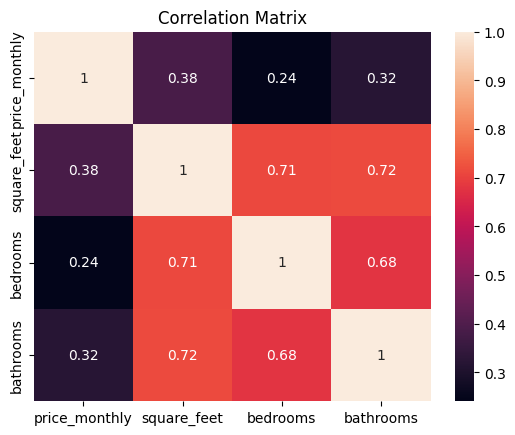

In [21]:
# dependency
import seaborn as sns

corr = df[["price_monthly", "square_feet", "bedrooms", "bathrooms"]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()



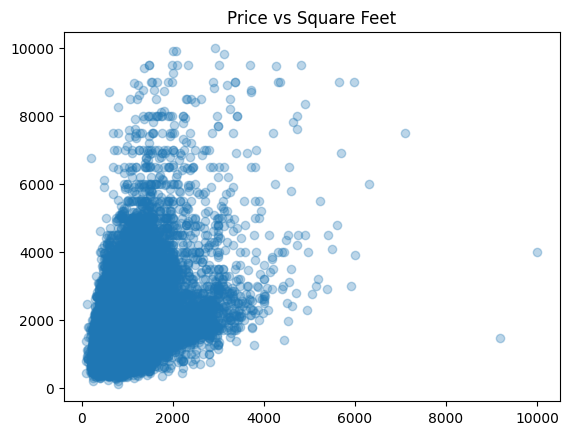

In [22]:
#relational graph
plt.figure()
plt.scatter(df["square_feet"], df["price_monthly"], alpha=0.3)
plt.title("Price vs Square Feet")
plt.show()

The correlation matrix shows that structural features such as square footage, number of bedrooms, and number of bathrooms are moderately correlated with price, with square footage having the strongest relationship (0.38). This indicates that no single feature fully explains price variation, and multiple factors must be considered together.

Additionally, there is strong correlation among the structural features themselves (e.g., square footage and bathrooms: 0.72), indicating multicollinearity. This suggests that regularized models such as Ridge regression may be more appropriate than standard linear regression.

The scatter plot between price and square footage further reveals a positive but non-linear relationship. Price increases with size, but at a decreasing rate, indicating diminishing returns. Furthermore, the spread of data points increases with size, suggesting heteroskedasticity. These patterns motivate the use of log transformation and more flexible modeling approaches.

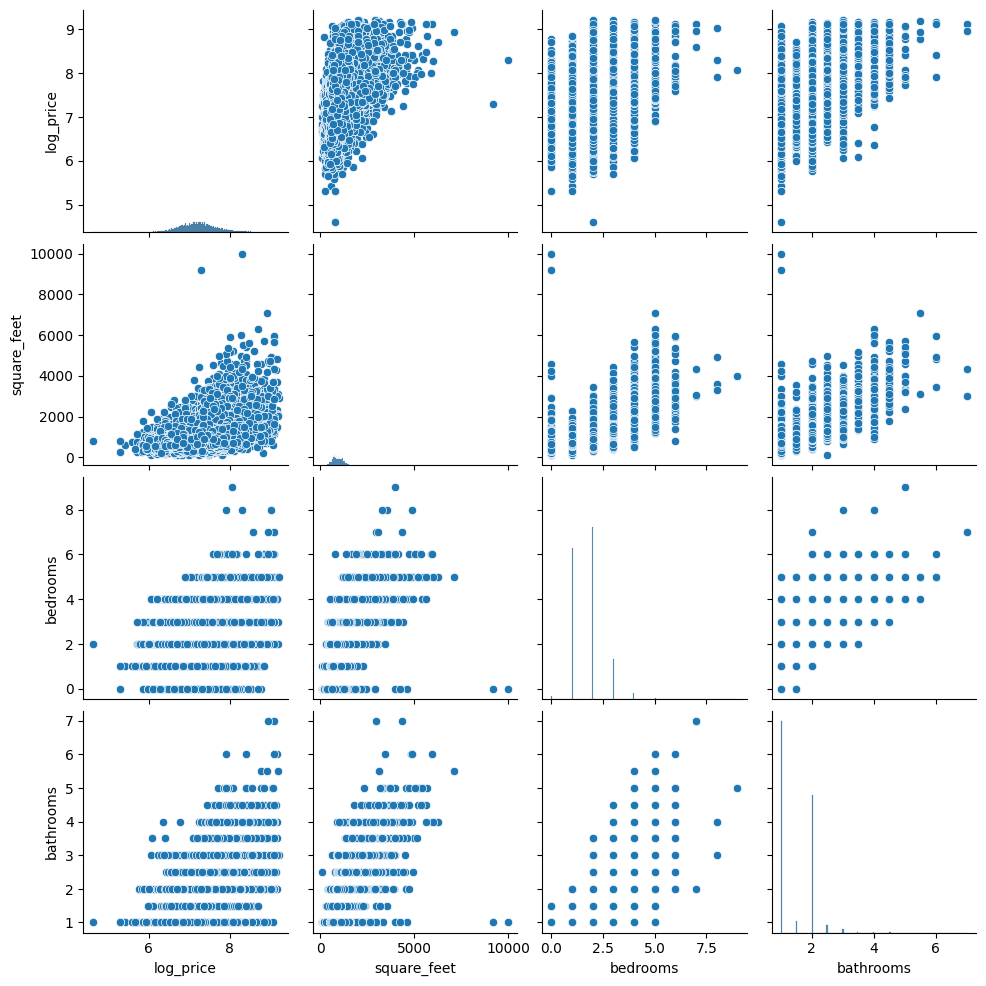

In [23]:
sns.pairplot(df[["log_price", "square_feet", "bedrooms", "bathrooms"]])

The pairplot provides a more detailed view of the relationships between variables. The relationship between log-transformed price and square footage shows a clear positive trend, but with a non-linear pattern and increasing variance, indicating heteroskedasticity.

For discrete variables such as bedrooms and bathrooms, the relationship with price appears in grouped vertical patterns, suggesting that these features influence price in a stepwise manner rather than continuously.

Additionally, strong relationships are observed among structural features (e.g., square footage and number of bedrooms), confirming the presence of multicollinearity. These observations support the use of regularized models and potentially non-linear modeling approaches.

## 2.3 Categorical variable analysis

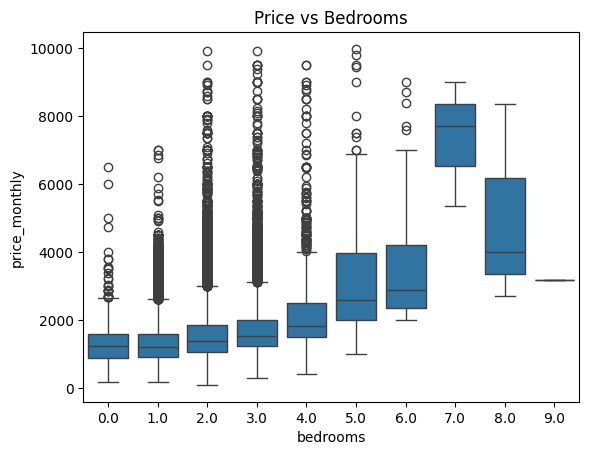

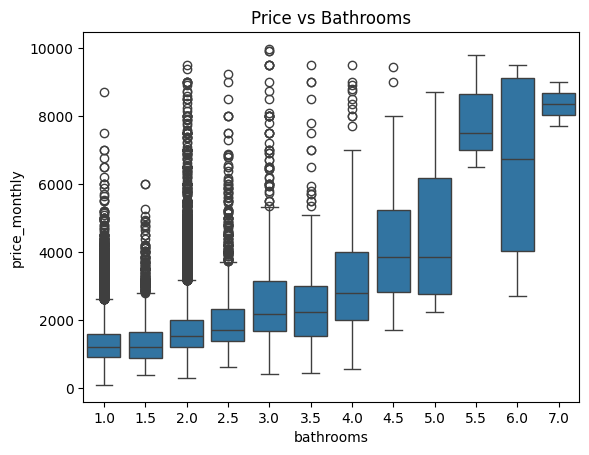

In [24]:
# Categorical numerical variable
plt.figure()
sns.boxplot(x=df["bedrooms"], y=df["price_monthly"])
plt.title("Price vs Bedrooms")
plt.show()

plt.figure()
sns.boxplot(x=df["bathrooms"], y=df["price_monthly"])
plt.title("Price vs Bathrooms")
plt.show()

Bedrooms and bathrooms have a clear impact on price, but they cannot fully explain price variation due to large dispersion, indicating the importance of additional features such as location and amenities.

Log transformation makes the price distribution more stable and closer to symmetric, making it more suitable for modeling.

Structural features such as square footage, bedrooms, and bathrooms show a positive relationship with price, but the relationship is not linear. Instead, it becomes more dispersed for larger properties, indicating heteroskedasticity and possible market segmentation.

In addition, large price variation exists within the same number of bedrooms or bathrooms, suggesting that structural features alone are insufficient to explain price, and other factors such as location and amenities play an important role.

### Price Distribution

The original price is right-skewed with extreme high values.  
After log transformation, the distribution becomes more symmetric and suitable for modeling.

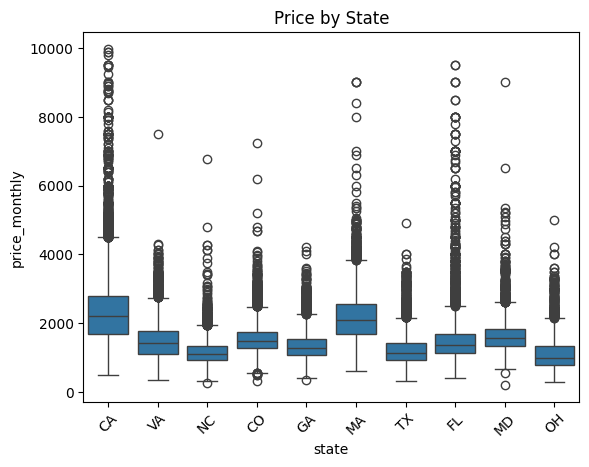

In [25]:
# state
top_states = df["state"].value_counts().head(10).index

plt.figure()
sns.boxplot(x=df[df["state"].isin(top_states)]["state"],
            y=df[df["state"].isin(top_states)]["price_monthly"])
plt.xticks(rotation=45)
plt.title("Price by State")
plt.show()

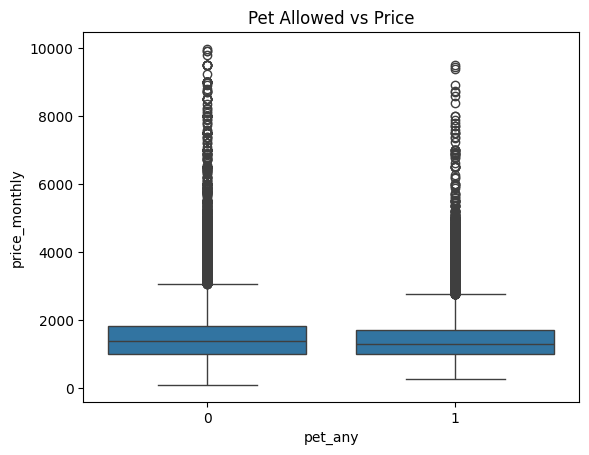

In [26]:
#pets
sns.boxplot(x=df["pet_any"], y=df["price_monthly"])
plt.title("Pet Allowed vs Price")
plt.show()

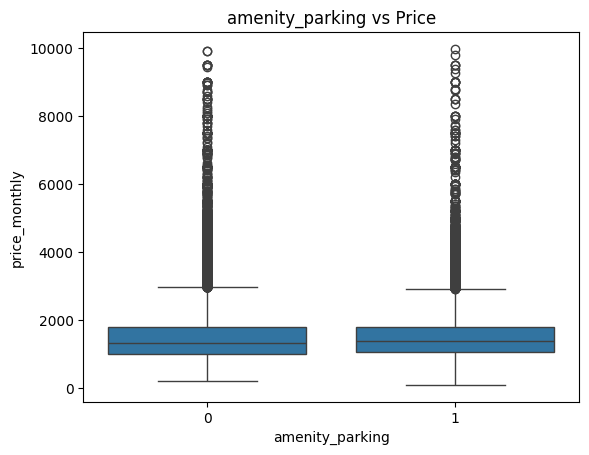

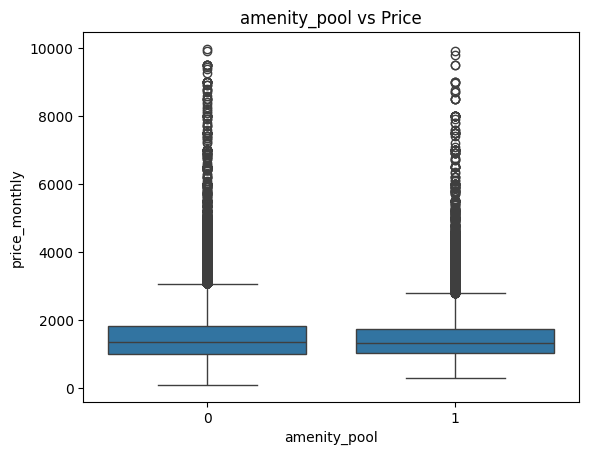

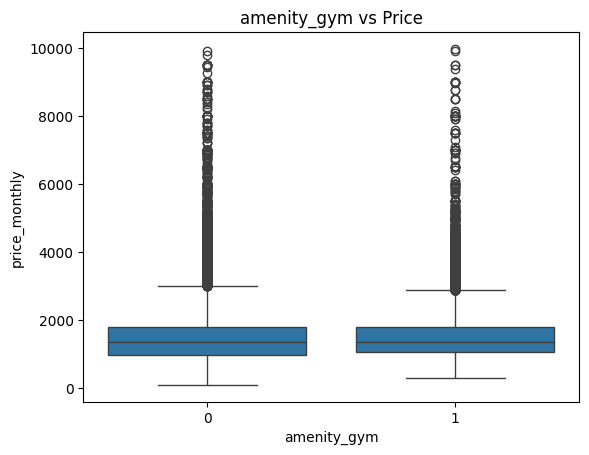

In [27]:
#amenities
for col in ["amenity_parking", "amenity_pool", "amenity_gym"]:
    sns.boxplot(x=df[col], y=df["price_monthly"])
    plt.title(f"{col} vs Price")
    plt.show()

The analysis of categorical variables shows that location (state) has a significant impact on rental prices, while features such as pet policy and amenities have relatively weak effects. However, these weaker effects may be due to the influence of dominant factors like location and property size, which mask their true contribution. Therefore, further conditional analysis is required.

The EDA results indicate that location variables such as state have a dominant effect on rental prices, while amenities and pet policies show relatively weaker influence. Therefore, in the baseline model, we prioritize structural and location-related features. However, amenities and pet-related variables are retained for further analysis, as they may provide additional explanatory power when combined with other variables.

## 2.4 Geographic analysis

In [28]:
#Preparing the Database Environment
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Copy the data to avoid contaminating the original table.
df_eda = df.copy()

# Only keep the columns needed for analysis
cols_needed = ["price_monthly", "state", "cityname", "latitude", "longitude"]
df_eda = df_eda[cols_needed].copy()

# Drop rows with missing values in key columns
df_eda = df_eda.dropna(subset=["price_monthly", "state", "latitude", "longitude"])

# If the city name is missing, you can fill in "Unknown".
if "cityname" in df_eda.columns:
    df_eda["cityname"] = df_eda["cityname"].fillna("Unknown")

# Take the logarithm of the price.
df_eda["log_price"] = np.log1p(df_eda["price_monthly"])

print(df_eda.shape)
df_eda.head()

(99237, 6)


,price_monthly,state,cityname,latitude,longitude,log_price
0,2195.0,CA,Redondo Beach,33.8520,-118.3759,7.694393
1,1250.0,VA,Newport News,37.0867,-76.4941,7.131699
2,1395.0,NC,Raleigh,35.8230,-78.6438,7.241366
3,1600.0,CA,Vacaville,38.3622,-121.9712,7.378384
4,975.0,NM,Albuquerque,35.1038,-106.6110,6.883463


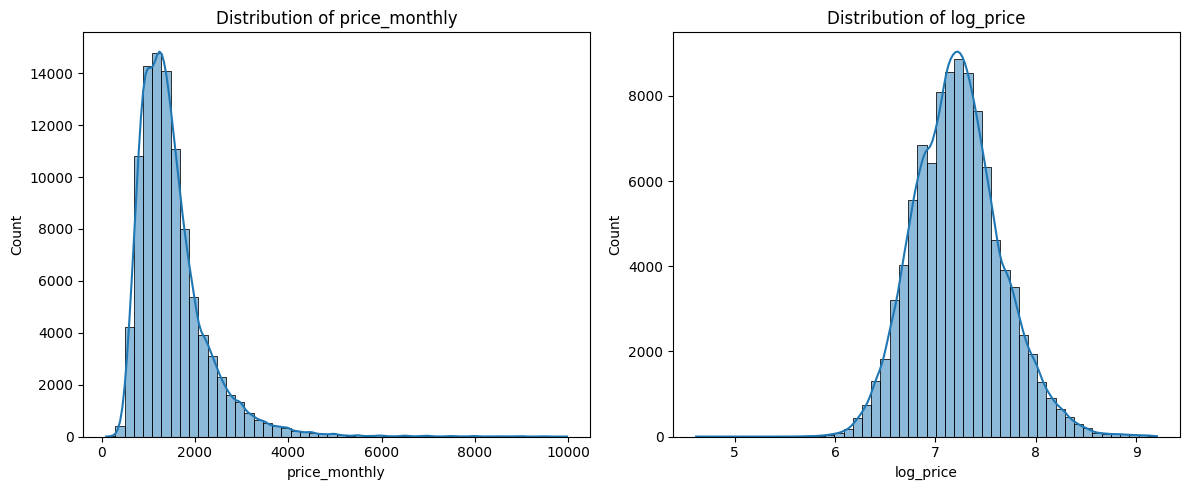

In [29]:
#  distribution of price and log_price
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_eda["price_monthly"], bins=50, kde=True)
plt.title("Distribution of price_monthly")

plt.subplot(1, 2, 2)
sns.histplot(df_eda["log_price"], bins=50, kde=True)
plt.title("Distribution of log_price")

plt.tight_layout()
plt.show()

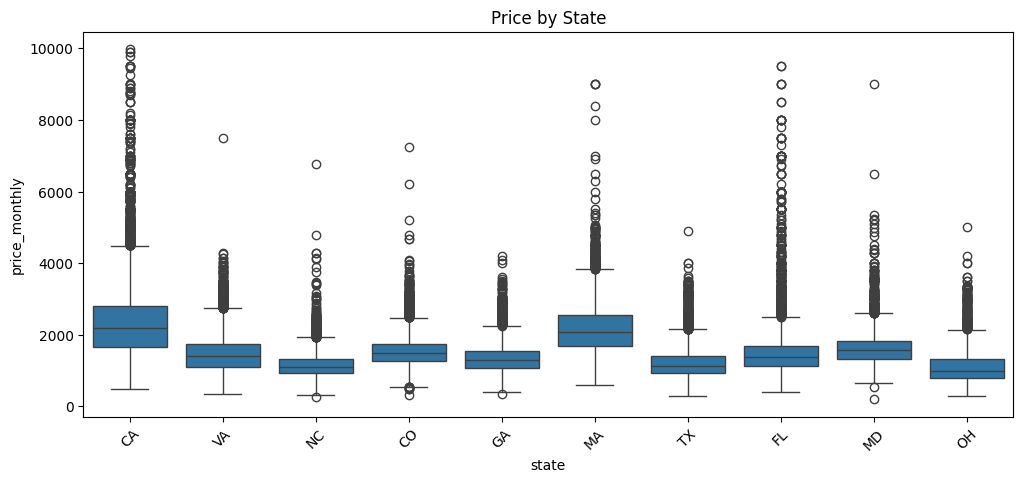

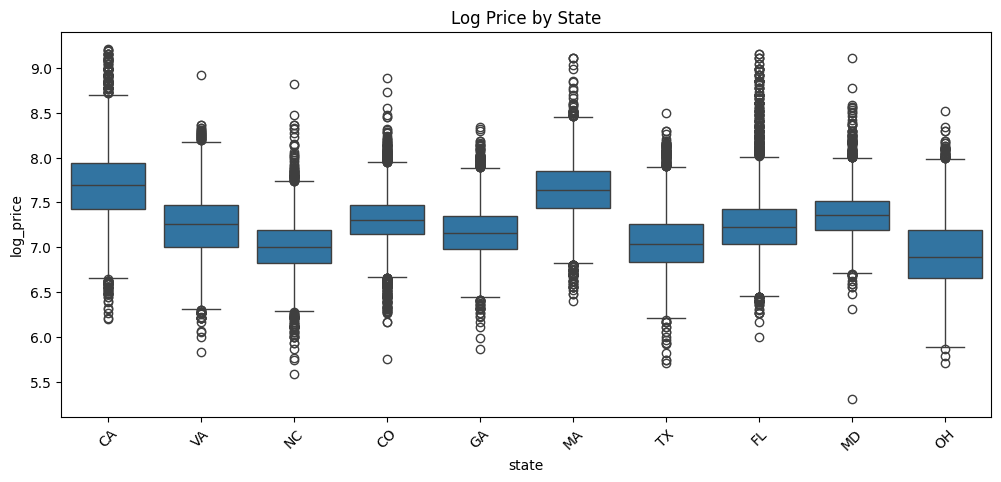

In [30]:
# State and price/log price
# top 10 states with the largest sample size
top_states = df_eda["state"].value_counts().head(10).index
df_state = df_eda[df_eda["state"].isin(top_states)].copy()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_state, x="state", y="price_monthly")
plt.xticks(rotation=45)
plt.title("Price by State")
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_state, x="state", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by State")
plt.show()

In [31]:
#Compare the central position
state_summary = (
    df_eda.groupby("state")
    .agg(
        count=("price_monthly", "size"),
        median_price=("price_monthly", "median"),
        mean_price=("price_monthly", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values("count", ascending=False)
)

state_summary.head(15)

,count,median_price,mean_price,median_log_price
state,,,,
TX,11248,1140.0,1217.572546,7.039660
CA,10243,2195.0,2378.000586,7.694393
VA,8276,1411.0,1485.618052,7.252762
NC,6293,1099.0,1154.039568,7.003065
CO,6276,1479.0,1549.970363,7.299797
FL,5759,1370.0,1550.501823,7.223296
MD,5233,1575.0,1643.114657,7.362645
MA,5023,2080.0,2192.226757,7.640604
OH,4898,979.0,1110.110453,6.887553




Prices vary significantly across states, indicating that location plays an important role.  
However, large variation still exists within each state.v

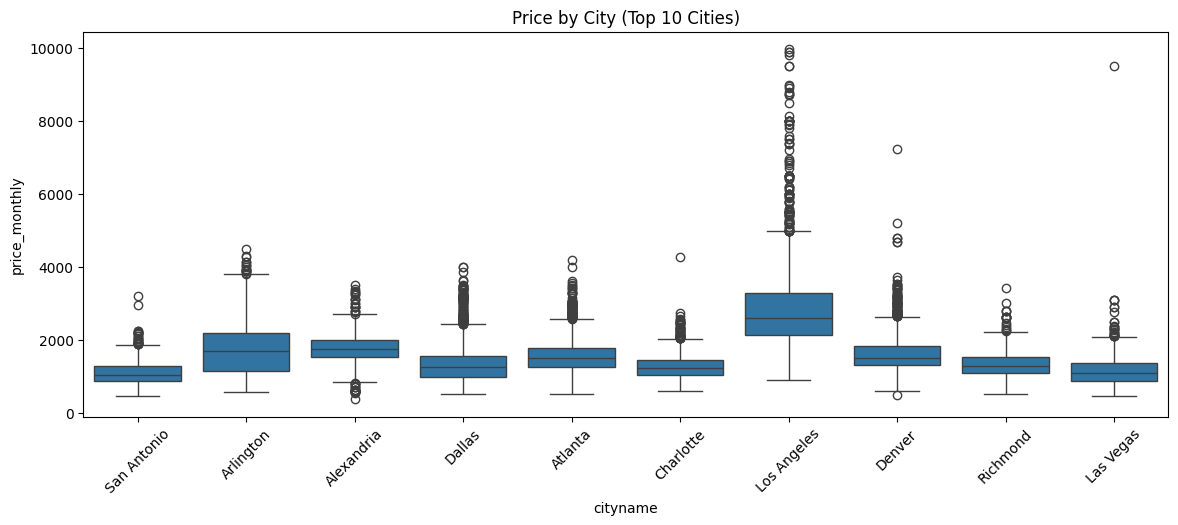

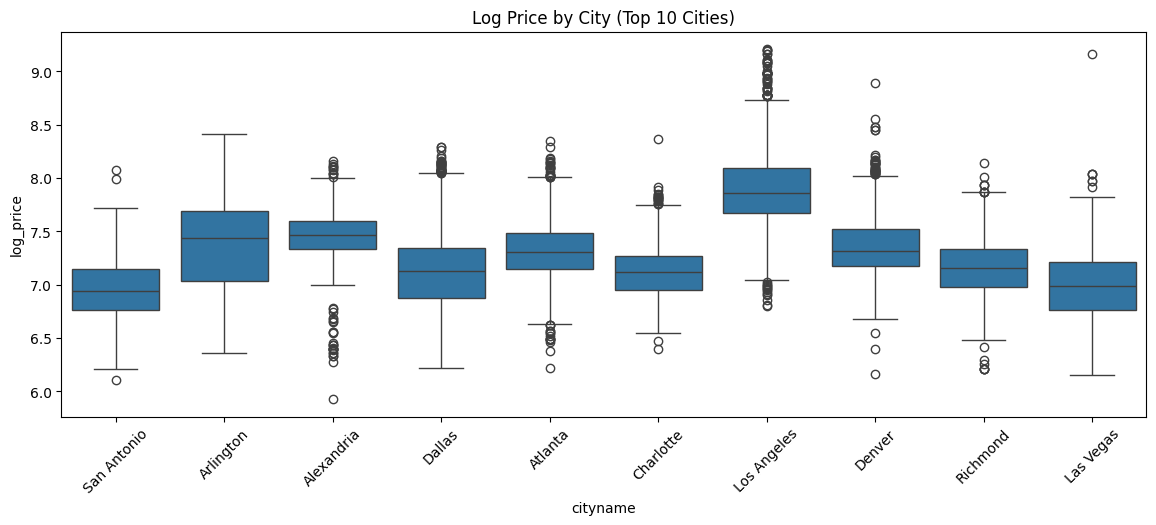

In [32]:
# City and Price/log price
top_cities = df_eda["cityname"].value_counts().head(10).index
df_city = df_eda[df_eda["cityname"].isin(top_cities)].copy()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_city, x="cityname", y="price_monthly")
plt.xticks(rotation=45)
plt.title("Price by City (Top 10 Cities)")
plt.show()

plt.figure(figsize=(14, 5))
sns.boxplot(data=df_city, x="cityname", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by City (Top 10 Cities)")
plt.show()

In [33]:
city_summary = (
    df_eda.groupby("cityname")
    .agg(
        count=("price_monthly", "size"),
        median_price=("price_monthly", "median"),
        mean_price=("price_monthly", "mean"),
        median_log_price=("log_price", "median")
    )
    .sort_values("count", ascending=False)
)

city_summary.head(15)

,count,median_price,mean_price,median_log_price
cityname,,,,
Dallas,2856,1247.0,1336.984594,7.129298
Denver,2749,1499.0,1617.913423,7.313220
Los Angeles,2402,2600.0,2833.067860,7.863651
Las Vegas,1846,1080.5,1132.684182,6.986104
Arlington,1577,1700.0,1754.163602,7.438972
Atlanta,1504,1495.0,1598.846410,7.310550
Charlotte,1122,1229.0,1287.259358,7.114769
Richmond,914,1280.0,1312.852298,7.155396
Alexandria,914,1745.0,1781.623632,7.465083


City-level differences are more pronounced than state-level differences.  
This suggests that finer geographic information better explains price variation.

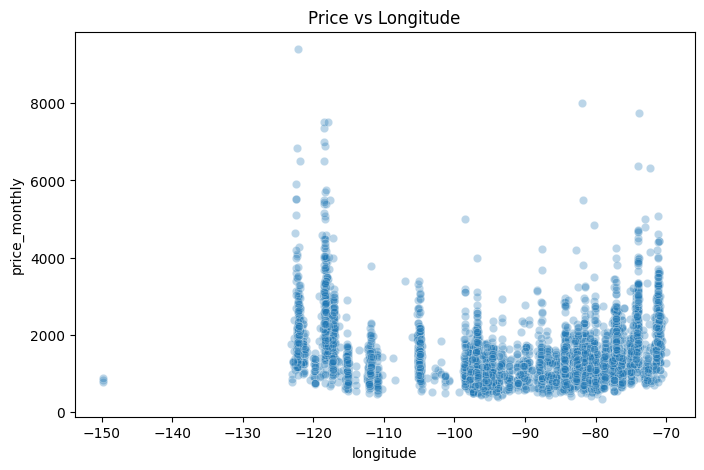

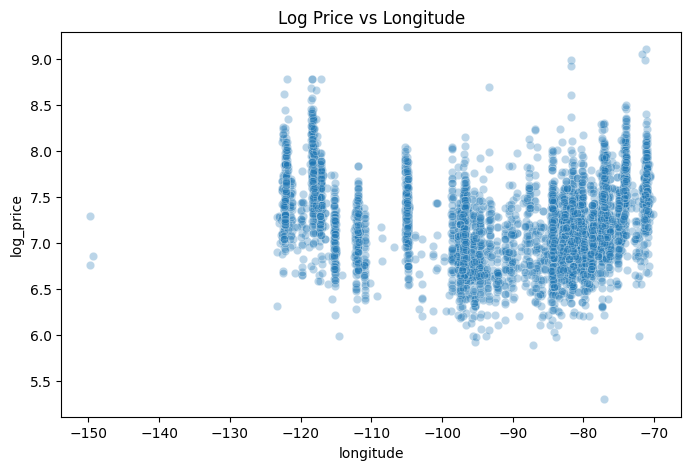

In [34]:
# Longitude vs. price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="longitude", y="price_monthly", alpha=0.3)
plt.title("Price vs Longitude")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="longitude", y="log_price", alpha=0.3)
plt.title("Log Price vs Longitude")
plt.show()

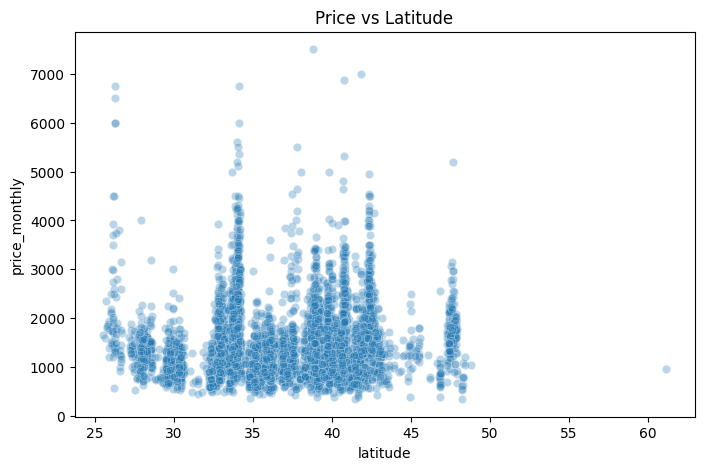

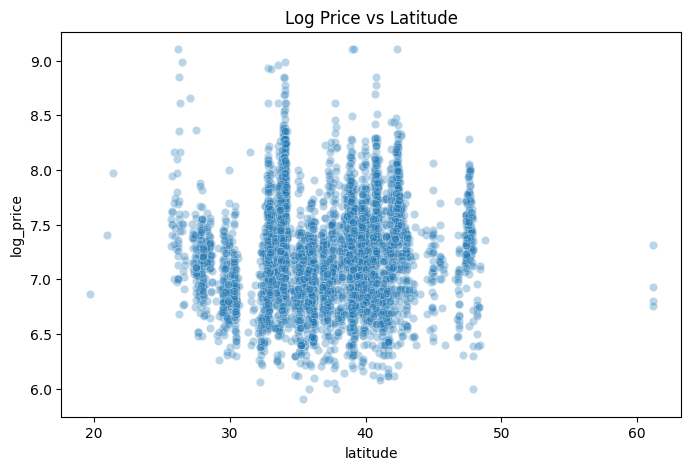

In [35]:
# Latitude vs. Price
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="latitude", y="price_monthly", alpha=0.3)
plt.title("Price vs Latitude")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_eda.sample(min(5000, len(df_eda))), x="latitude", y="log_price", alpha=0.3)
plt.title("Log Price vs Latitude")
plt.show()

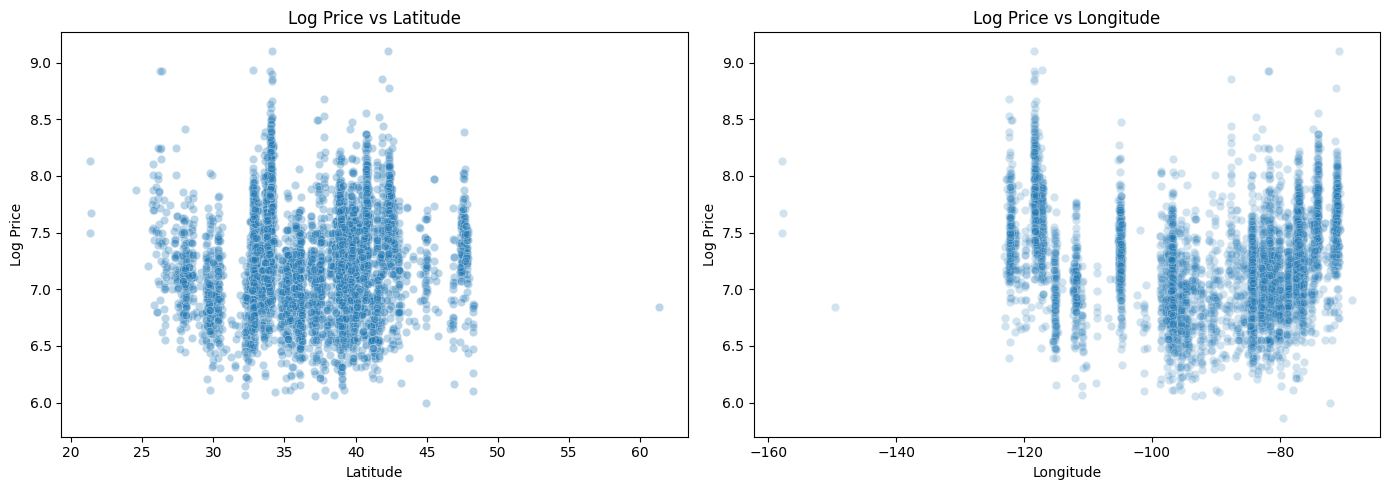

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sample_df = df_eda.sample(min(5000, len(df_eda)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


sns.scatterplot(
    data=sample_df,
    x="latitude",
    y="log_price",
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title("Log Price vs Latitude")
axes[0].set_xlabel("Latitude")
axes[0].set_ylabel("Log Price")


sns.scatterplot(
    data=sample_df,
    x="longitude",
    y="log_price",
    alpha=0.2,
    ax=axes[1]
)
axes[1].set_title("Log Price vs Longitude")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Log Price")

plt.tight_layout()
plt.show()

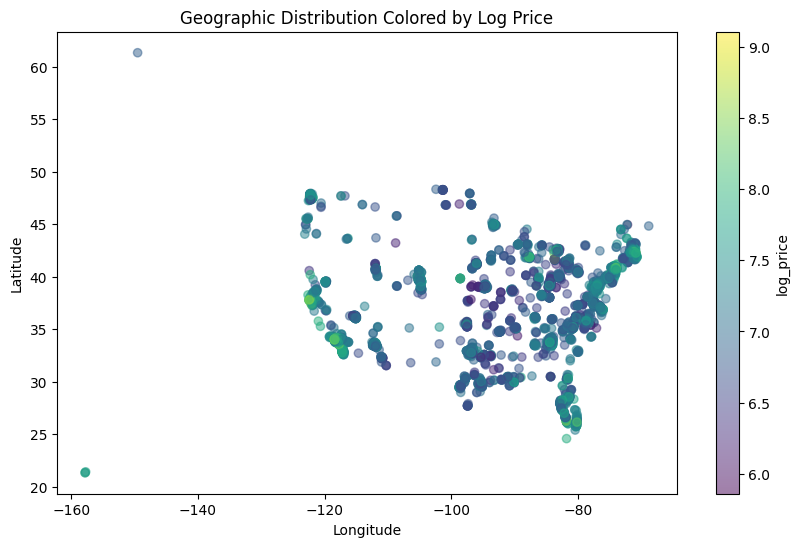

In [37]:
# Two-dimensional scatter plot of geographical locations, colored by price
sample_geo = df_eda.sample(min(5000, len(df_eda)), random_state=42)

plt.figure(figsize=(10, 6))
plt.scatter(sample_geo["longitude"], sample_geo["latitude"], c=sample_geo["log_price"], alpha=0.5)
plt.colorbar(label="log_price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution Colored by Log Price")
plt.show()

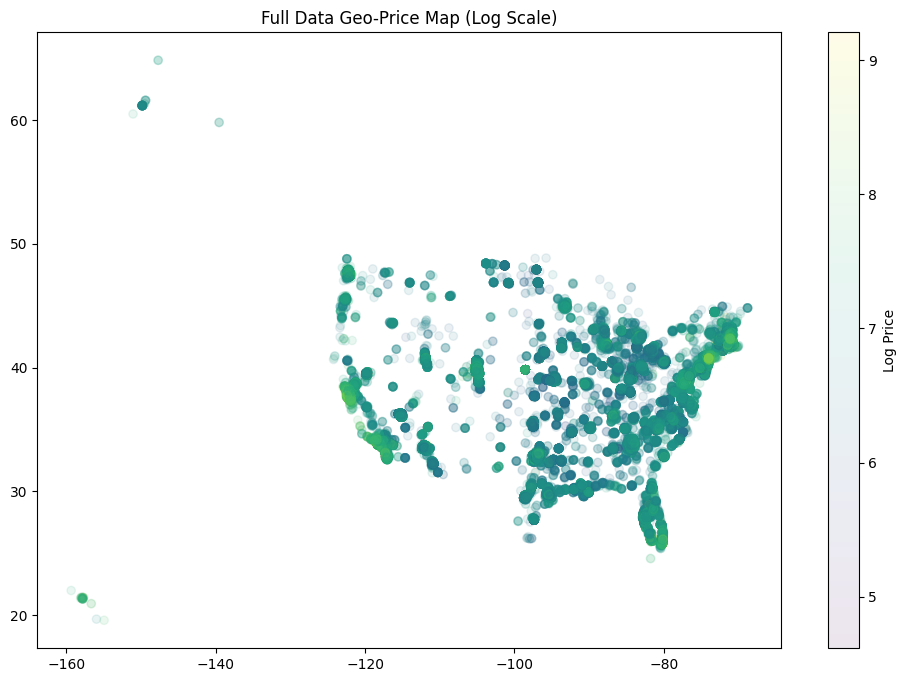

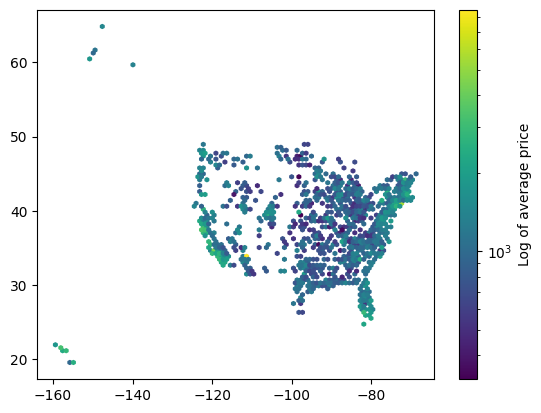

In [38]:
plt.figure(figsize=(12, 8))

# 1. Greatly reduce the size of the point (s = 1 or smaller)
# 2. Increase transparency (alpha=0.1 or lower) to show density in overlapping areas
plt.scatter(df["lon"], df["lat"], 
            c=np.log1p(df["price_monthly"]), # still use Log
            alpha=0.1,    # let points be transparent, overlapping areas will show density
            cmap='viridis')

plt.colorbar(label="Log Price")
plt.title("Full Data Geo-Price Map (Log Scale)")
plt.show()
plt.hexbin(df["lon"], df["lat"], C=df["price_monthly"], 
           gridsize=100, cmap='viridis', bins='log') 
plt.colorbar(label='Log of average price')

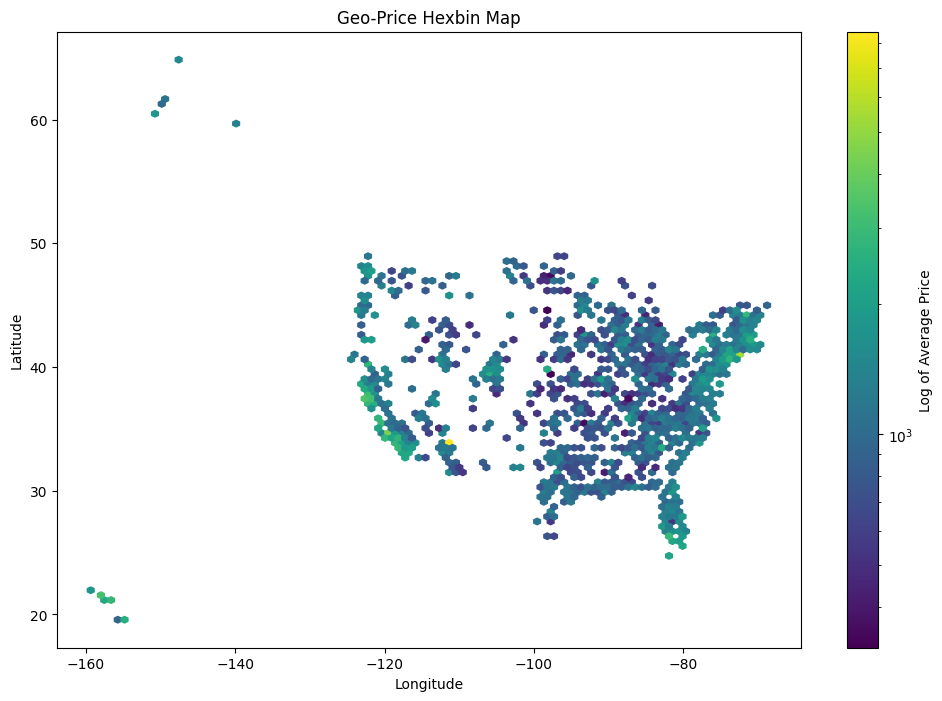

In [39]:
plt.figure(figsize=(12, 8))

hb = plt.hexbin(
    df["lon"],
    df["lat"],
    C=df["price_monthly"],
    reduce_C_function=np.mean,
    gridsize=100,
    cmap="viridis",
    bins="log"
)

plt.colorbar(hb, label="Log of Average Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geo-Price Hexbin Map")
plt.show()

In [40]:
# Urban interpretive power
def eta_squared(df, cat_col, target_col):
    df_temp = df[[cat_col, target_col]].dropna().copy()
    
    # 总体均值
    grand_mean = df_temp[target_col].mean()
    
    # 组间平方和（Between-group variance）
    ss_between = sum(
        len(group) * (group[target_col].mean() - grand_mean) ** 2
        for _, group in df_temp.groupby(cat_col)
    )
    
    # Total variance
    ss_total = sum((df_temp[target_col] - grand_mean) ** 2)
    
    return ss_between / ss_total if ss_total != 0 else np.nan
city_counts = df_eda["cityname"].value_counts()
valid_cities = city_counts[city_counts >= 30].index

df_city_valid = df_eda[df_eda["cityname"].isin(valid_cities)].copy()

print("City -> price_monthly:", eta_squared(df_city_valid, "cityname", "price_monthly"))
print("City -> log_price:", eta_squared(df_city_valid, "cityname", "log_price"))

City -> price_monthly: 0.525780776901699
City -> log_price: 0.5385516911031814


In [41]:
# Correlation of longitude and latitude
corr_cols = ["price_monthly", "log_price", "latitude", "longitude"]
print(df_eda[corr_cols].corr())

               price_monthly  log_price  latitude  longitude
price_monthly       1.000000   0.938091  0.077589  -0.108537
log_price           0.938091   1.000000  0.094601  -0.089424
latitude            0.077589   0.094601  1.000000   0.079142
longitude          -0.108537  -0.089424  0.079142   1.000000


### Price vs Latitude and Longitude

Latitude and longitude do not show strong linear relationships with price.  
However, clear spatial clusters can be observed in geographic plots.

### fixed variate

(24934, 40)


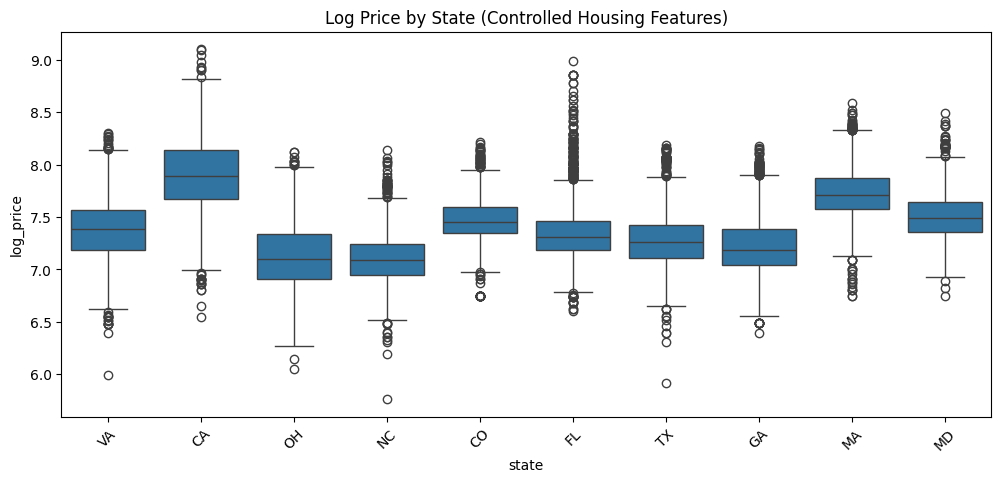

In [42]:
# Choose a "standard room type"
df_control = df[
    (df["square_feet"] >= 1000) &
    (df["square_feet"] <= 1500) &
    (df["bedrooms"] == 2) &
    (df["bathrooms"] >= 1) & (df["bathrooms"] <= 2)
].copy()

print(df_control.shape)

# influence of state
top_states = df_control["state"].value_counts().head(10).index
df_control_state = df_control[df_control["state"].isin(top_states)]

plt.figure(figsize=(12,5))
sns.boxplot(data=df_control_state, x="state", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by State (Controlled Housing Features)")
plt.show()

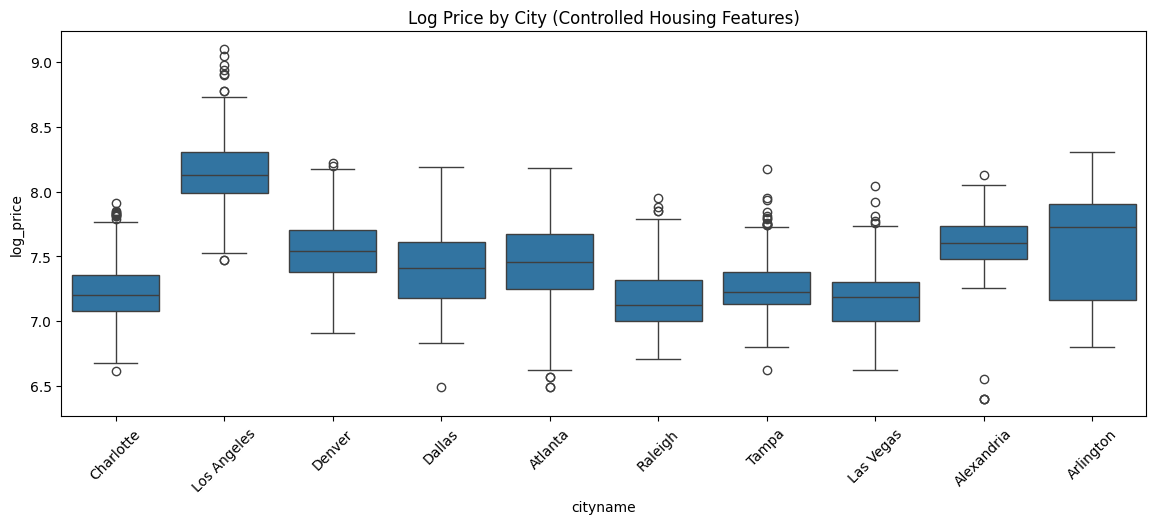

In [43]:
#influence of city
top_cities = df_control["cityname"].value_counts().head(10).index
df_control_city = df_control[df_control["cityname"].isin(top_cities)]

plt.figure(figsize=(14,5))
sns.boxplot(data=df_control_city, x="cityname", y="log_price")
plt.xticks(rotation=45)
plt.title("Log Price by City (Controlled Housing Features)")
plt.show()

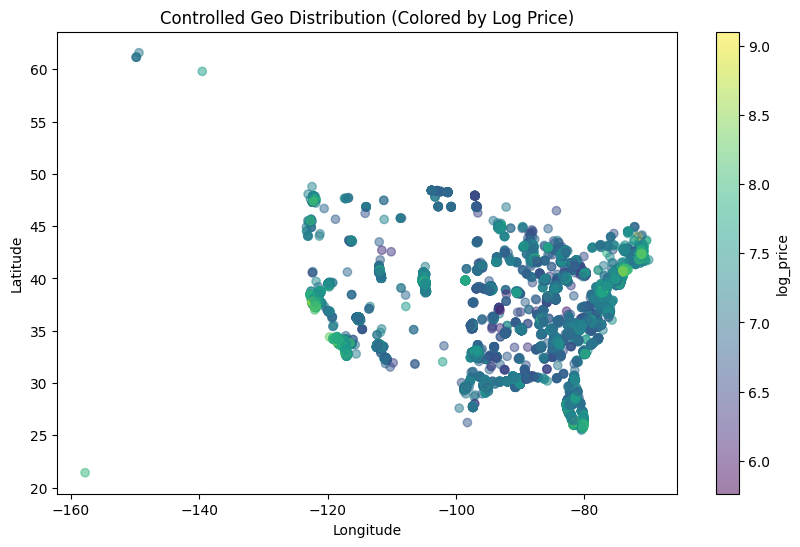

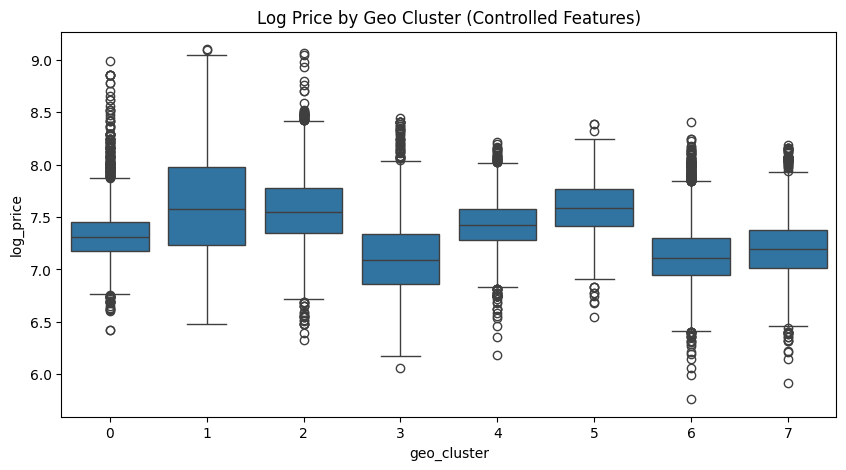

In [44]:
# Viewing longitude and latitude under controlled conditions
plt.figure(figsize=(10,6))
plt.scatter(df_control["longitude"], df_control["latitude"], 
            c=df_control["log_price"], alpha=0.5)
plt.colorbar(label="log_price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Controlled Geo Distribution (Colored by Log Price)")
plt.show()

#geo cluster
from sklearn.cluster import KMeans

df_control = df_control.dropna(subset=["latitude", "longitude"])

kmeans = KMeans(n_clusters=8, random_state=42)
df_control["geo_cluster"] = kmeans.fit_predict(df_control[["latitude", "longitude"]])
plt.figure(figsize=(10,5))
sns.boxplot(x="geo_cluster", y="log_price", data=df_control)
plt.title("Log Price by Geo Cluster (Controlled Features)")
plt.show()

### Geographic Distribution

Listings are concentrated in specific regions, and price levels vary across these regions.  
This indicates that rent is influenced by local market areas rather than continuous coordinates.

### Controlled Analysis

After controlling for housing features (size, bedrooms, bathrooms),  
price differences across locations still remain.  
This suggests that location has an independent effect on rent.

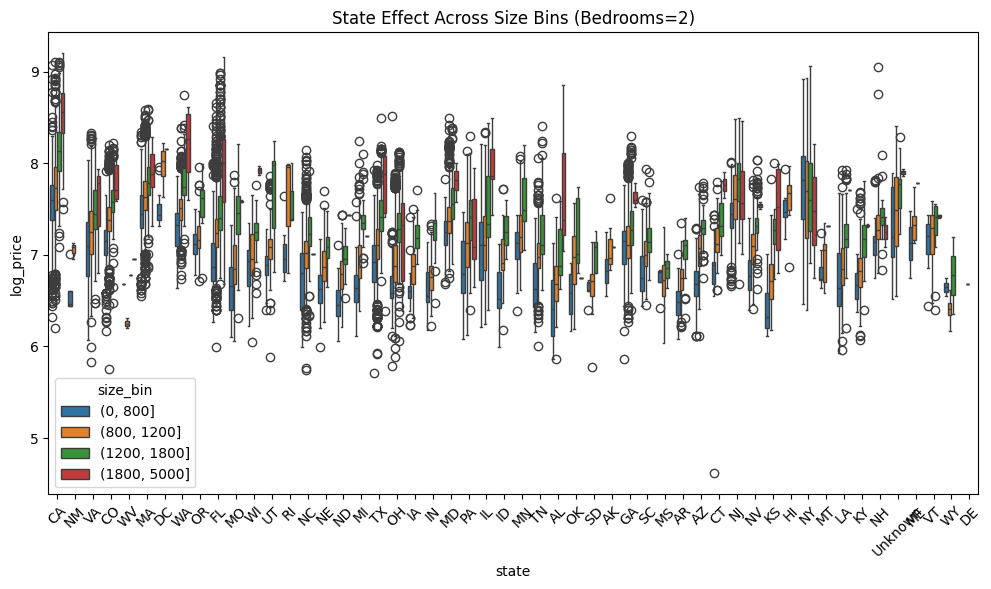

In [45]:
# Binning control
df["size_bin"] = pd.cut(df["square_feet"], bins=[0,800,1200,1800,5000])
df["bed_bin"] = df["bedrooms"]
subset = df[df["bedrooms"] == 2]

plt.figure(figsize=(12,6))
sns.boxplot(x="state", y="log_price", hue="size_bin", data=subset)
plt.xticks(rotation=45)
plt.title("State Effect Across Size Bins (Bedrooms=2)")
plt.show()

### State Effect Across Size Bins

Larger properties tend to have higher prices across all states.  
However, for the same size range, prices still vary significantly by state,  
confirming that geographic factors affect price independently of property size.

Although latitude and longitude do not show strong linear relationships with price, clear spatial clusters exist. After controlling for housing features, location still has a strong effect. Compared to state and city, geographic clustering better captures local market differences.

## EDA conclusion
Although latitude and longitude do not show strong linear relationships with price, the geographic distribution reveals clear spatial clusters. This suggests that rent is not driven by latitude or longitude separately, but by the localized market areas formed by their combination. After controlling for housing features, location still shows a strong effect on price, meaning that geographic differences cannot be explained only by property size or room count. Compared with state and city, geographic clustering provides a more data-driven and flexible way to capture local market differences.

# 3. Preliminary Modeling Check

In [46]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# 1️⃣ Handling Missing Values
df_model = df[["square_feet", "bedrooms", "bathrooms", "price_monthly", "log_price"]].dropna()

# 2️⃣ Defining X and y
X = df_model[["square_feet", "bedrooms", "bathrooms"]]
y1 = df_model["price_monthly"]
y2 = df_model["log_price"]

# 3️⃣ Splitting the data
X_train, X_test, y1_train, y1_test = train_test_split(X, y1, test_size=0.2, random_state=42)
_, _, y2_train, y2_test = train_test_split(X, y2, test_size=0.2, random_state=42)

# 4️⃣ Model (raw price)
model1 = LinearRegression()
model1.fit(X_train, y1_train)
pred1 = model1.predict(X_test)

# 5️⃣ Model (log price)
model2 = LinearRegression()
model2.fit(X_train, y2_train)
pred2 = model2.predict(X_test)

# 6️⃣ Output Results
print("MAE (raw price):", mean_absolute_error(y1_test, pred1))
print("MAE (log price):", mean_absolute_error(y2_test, pred2))

MAE (raw price): 491.18478510091273
MAE (log price): 0.31391966613916666


# 4.Ridge Regression Formal Modeling

## Baseline Ridge model

In [47]:
# Formal baseline dataset
# Formal baseline dataset
df_baseline = df[["square_feet", "bedrooms", "bathrooms", "state", "log_price"]].dropna().copy()

print(df_baseline.shape)
df_baseline.head()

# Handle categorical variables
df_baseline = pd.get_dummies(df_baseline, columns=["state"], drop_first=True)

#Define X and y
X = df_baseline.drop(columns=["log_price"])
y = df_baseline["log_price"]


(99057, 5)


In [48]:
# split data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)

(79245, 54) (19812, 54)


In [49]:
# Train baseline model
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

baseline_model = Ridge(alpha=1.0)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline MAE:", mean_absolute_error(y_test, y_pred))
print("Baseline RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Baseline MAE: 0.2191879053200354
Baseline RMSE: 0.28766335603794957


### Baseline modeling
A baseline Ridge regression model was built using structural features (`square_feet`, `bedrooms`, `bathrooms`) and state-level location information. The model was trained on 80% of the data and tested on the remaining 20%.

The baseline results show that these variables provide a reasonable first explanation of rental price differences, but prediction errors remain. This suggests that state-level geography may be too coarse to fully capture localized rental market patterns, motivating the next step of using geographic clustering.

## 4.2 Cluster-only model

In [50]:
from sklearn.cluster import KMeans
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []

for k in [10, 20, 30]:
    
    # 1️⃣ Regenerate the cluster (without overwriting other experiments)
    df["geo_cluster"] = KMeans(n_clusters=k, random_state=42)\
                        .fit_predict(df[["latitude", "longitude"]])
    
    # 2️⃣ Build the dataset
    df_cluster = df[[
        "square_feet",
        "bedrooms",
        "bathrooms",
        "geo_cluster",
        "log_price"
    ]].dropna().copy()
    
    df_cluster = pd.get_dummies(df_cluster, columns=["geo_cluster"], drop_first=True)
    
    # 3️⃣ Define X and y
    X_cluster = df_cluster.drop(columns=["log_price"])
    y_cluster = df_cluster["log_price"]
    
    # 4️⃣ Use baseline's index (crucial!)
    X_train_c = X_cluster.loc[X_train.index]
    X_test_c = X_cluster.loc[X_test.index]
    y_train_c = y_cluster.loc[y_train.index]
    y_test_c = y_cluster.loc[y_test.index]
    
    # 5️⃣ Train the model
    model = Ridge(alpha=1.0)
    model.fit(X_train_c, y_train_c)
    
    y_pred = model.predict(X_test_c)
    
    mae = mean_absolute_error(y_test_c, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test_c, y_pred))
    
    results.append((k, mae, rmse))

# 6️⃣ Output results
for r in results:
    print(f"k={r[0]} | MAE={r[1]:.4f} | RMSE={r[2]:.4f}")

k=10 | MAE=0.2641 | RMSE=0.3389
k=20 | MAE=0.2279 | RMSE=0.2991
k=30 | MAE=0.2186 | RMSE=0.2893


The results show that the cluster-based models do not significantly outperform the baseline model using state-level information. 

When the number of clusters is small (k=10), the model performs substantially worse, indicating that coarse geographic grouping fails to capture meaningful differences in local rental markets. 

As the number of clusters increases (k=20 and k=30), the performance improves and approaches the baseline. This suggests that finer spatial segmentation better reflects local market conditions. 

However, even with k=30, the cluster model only slightly improves MAE while slightly worsening RMSE, indicating no clear advantage over the state-based representation. 

Overall, this suggests that state-level geographic information already captures a strong portion of rental price variation, and clustering based on latitude and longitude does not provide substantial additional predictive power in this setting.

## 4.3 Combined model: state + geo cluster

In [51]:
# =========================
# Combined model: state + geo_cluster
# =========================

from sklearn.cluster import KMeans
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# 1. Create geo_cluster with k=30
df["geo_cluster_30"] = KMeans(n_clusters=30, random_state=42).fit_predict(
    df[["latitude", "longitude"]]
)

# 2. Build combined dataset
df_combined = df[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "geo_cluster_30",
    "log_price"
]].dropna().copy()

# 3. One-hot encode state and geo_cluster
df_combined = pd.get_dummies(
    df_combined,
    columns=["state", "geo_cluster_30"],
    drop_first=True
)

# 4. Define X and y
X_combined = df_combined.drop(columns=["log_price"])
y_combined = df_combined["log_price"]

# 5. Use the SAME train/test index as baseline
X_combined_train = X_combined.loc[X_train.index]
X_combined_test = X_combined.loc[X_test.index]

y_combined_train = y_combined.loc[y_train.index]
y_combined_test = y_combined.loc[y_test.index]

# 6. Train model
combined_model = Ridge(alpha=1.0)
combined_model.fit(X_combined_train, y_combined_train)

# 7. Predict and evaluate
y_combined_pred = combined_model.predict(X_combined_test)

combined_mae = mean_absolute_error(y_combined_test, y_combined_pred)
combined_rmse = np.sqrt(mean_squared_error(y_combined_test, y_combined_pred))

print("Combined MAE:", combined_mae)
print("Combined RMSE:", combined_rmse)



Combined MAE: 0.2082350952691847
Combined RMSE: 0.27580347993209176


The combined model significantly outperforms both the baseline and cluster-only models. 

This indicates that geographic clusters capture additional local market variation that is not fully explained by state-level information alone. 

While clusters cannot replace traditional geographic variables such as state, they provide complementary information that improves predictive performance when used together.

# 5. Random Forest Models

## 5.1 Random Forest Baseline: state

In [52]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# ---------------------------
# 5.1 Random Forest Baseline
# ---------------------------

df_rf_baseline = df[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "log_price"
]].dropna().copy()

# One-hot encode state
df_rf_baseline = pd.get_dummies(df_rf_baseline, columns=["state"], drop_first=True)

# Define X and y
X_rf_base = df_rf_baseline.drop(columns=["log_price"])
y_rf_base = df_rf_baseline["log_price"]

# Use the same train/test split idea
X_train_rf_base, X_test_rf_base, y_train_rf_base, y_test_rf_base = train_test_split(
    X_rf_base, y_rf_base, test_size=0.2, random_state=42
)

# Train model
rf_baseline = RandomForestRegressor(
    n_estimators=1000,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train_rf_base, y_train_rf_base)

# Predict
y_pred_rf_base = rf_baseline.predict(X_test_rf_base)

# Evaluate
mae_rf_base = mean_absolute_error(y_test_rf_base, y_pred_rf_base)
rmse_rf_base = np.sqrt(mean_squared_error(y_test_rf_base, y_pred_rf_base))

print("Random Forest Baseline MAE:", mae_rf_base)
print("Random Forest Baseline RMSE:", rmse_rf_base)

Random Forest Baseline MAE: 0.18051055892361464
Random Forest Baseline RMSE: 0.2603637301674518


## 5.2 Random Forest + geo_cluster

In [53]:
from sklearn.cluster import KMeans

# ---------------------------
# 5.2 Random Forest + geo_cluster
# ---------------------------

results_rf_cluster = []

for k in [10, 20, 30]:
    
    df["geo_cluster"] = KMeans(n_clusters=k, random_state=42).fit_predict(
        df[["latitude", "longitude"]]
    )
    
    df_rf_cluster = df[[
        "square_feet",
        "bedrooms",
        "bathrooms",
        "geo_cluster",
        "log_price"
    ]].dropna().copy()
    
    # One-hot encode geo_cluster
    df_rf_cluster = pd.get_dummies(df_rf_cluster, columns=["geo_cluster"], drop_first=True)
    
    # Define X and y
    X_rf_cluster = df_rf_cluster.drop(columns=["log_price"])
    y_rf_cluster = df_rf_cluster["log_price"]
    
    # Create split
    X_train_rf_c, X_test_rf_c, y_train_rf_c, y_test_rf_c = train_test_split(
        X_rf_cluster, y_rf_cluster, test_size=0.2, random_state=42
    )
    
    # Train model
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_rf_c, y_train_rf_c)
    
    # Predict
    y_pred_rf_c = rf_model.predict(X_test_rf_c)
    
    # Evaluate
    mae_rf_c = mean_absolute_error(y_test_rf_c, y_pred_rf_c)
    rmse_rf_c = np.sqrt(mean_squared_error(y_test_rf_c, y_pred_rf_c))
    
    results_rf_cluster.append((k, mae_rf_c, rmse_rf_c))

for r in results_rf_cluster:
    print(f"RF k={r[0]} | MAE={r[1]:.4f} | RMSE={r[2]:.4f}")

RF k=10 | MAE=0.2274 | RMSE=0.3113
RF k=20 | MAE=0.1924 | RMSE=0.2737
RF k=30 | MAE=0.1821 | RMSE=0.2635


## 5.3 Random Forest Combined: state + geo_cluster

In [54]:
# ---------------------------
# 5.3 Random Forest Combined
# ---------------------------

results_rf_combined = []

for k in [10, 20, 30]:
    
    df["geo_cluster"] = KMeans(n_clusters=k, random_state=42).fit_predict(
        df[["latitude", "longitude"]]
    )
    
    df_rf_combined = df[[
        "square_feet",
        "bedrooms",
        "bathrooms",
        "state",
        "geo_cluster",
        "log_price"
    ]].dropna().copy()
    
    # One-hot encode state and geo_cluster
    df_rf_combined = pd.get_dummies(
        df_rf_combined,
        columns=["state", "geo_cluster"],
        drop_first=True
    )
    
    # Define X and y
    X_rf_combined = df_rf_combined.drop(columns=["log_price"])
    y_rf_combined = df_rf_combined["log_price"]
    
    # Create split
    X_train_rf_com, X_test_rf_com, y_train_rf_com, y_test_rf_com = train_test_split(
        X_rf_combined, y_rf_combined, test_size=0.2, random_state=42
    )
    
    # Train model
    rf_combined = RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    )
    
    rf_combined.fit(X_train_rf_com, y_train_rf_com)
    
    # Predict
    y_pred_rf_com = rf_combined.predict(X_test_rf_com)
    
    # Evaluate
    mae_rf_com = mean_absolute_error(y_test_rf_com, y_pred_rf_com)
    rmse_rf_com = np.sqrt(mean_squared_error(y_test_rf_com, y_pred_rf_com))
    
    results_rf_combined.append((k, mae_rf_com, rmse_rf_com))

for r in results_rf_combined:
    print(f"RF Combined k={r[0]} | MAE={r[1]:.4f} | RMSE={r[2]:.4f}")

RF Combined k=10 | MAE=0.1779 | RMSE=0.2575
RF Combined k=20 | MAE=0.1750 | RMSE=0.2550
RF Combined k=30 | MAE=0.1673 | RMSE=0.2459


### Interpretation of Results

The Random Forest results reveal three key findings.

First, the baseline model using state-level geography already performs well, which confirms that location is an important driver of rental prices.

Second, geo-cluster alone does not always outperform state. This suggests that clustering based only on latitude and longitude may capture local spatial patterns, but it may also lose some broader regional context.

Third, the combined model consistently performs best, especially when `k=30`. This shows that state and geo-cluster contain different but complementary geographic information. State reflects broad market differences, while geo-cluster helps capture more detailed neighborhood-like variation.

# 6. XGBoost Regression Models

## 6.1 XGB Baseline: state

In [55]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [56]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
import numpy as np
import pandas as pd

# ---------------------------
# 6.1 XGB Baseline
# ---------------------------

df_xgb_baseline = df[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "log_price"
]].dropna().copy()

# One-hot encode state
df_xgb_baseline = pd.get_dummies(df_xgb_baseline, columns=["state"], drop_first=True)

# Define X and y
X_xgb_base = df_xgb_baseline.drop(columns=["log_price"])
y_xgb_base = df_xgb_baseline["log_price"]

# Use train/test split
from sklearn.model_selection import train_test_split

X_train_xgb_base, X_test_xgb_base, y_train_xgb_base, y_test_xgb_base = train_test_split(
    X_xgb_base, y_xgb_base, test_size=0.2, random_state=42
)

# Train model
xgb_baseline = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

xgb_baseline.fit(X_train_xgb_base, y_train_xgb_base)

# Predict
y_pred_xgb_base = xgb_baseline.predict(X_test_xgb_base)

# Evaluate
mae_xgb_base = mean_absolute_error(y_test_xgb_base, y_pred_xgb_base)
rmse_xgb_base = np.sqrt(mean_squared_error(y_test_xgb_base, y_pred_xgb_base))

print("XGB Baseline MAE:", mae_xgb_base)
print("XGB Baseline RMSE:", rmse_xgb_base)

XGB Baseline MAE: 0.20242096474126614
XGB Baseline RMSE: 0.2675534806358463


## 6.2 XGB + geo_cluster

In [57]:
# ---------------------------
# 6.2 XGB + geo_cluster
# ---------------------------

results_xgb_cluster = []

for k in [10, 20, 30]:
    
    df["geo_cluster"] = KMeans(n_clusters=k, random_state=42).fit_predict(
        df[["latitude", "longitude"]]
    )
    
    df_xgb_cluster = df[[
        "square_feet",
        "bedrooms",
        "bathrooms",
        "geo_cluster",
        "log_price"
    ]].dropna().copy()
    
    # One-hot encode geo_cluster
    df_xgb_cluster = pd.get_dummies(df_xgb_cluster, columns=["geo_cluster"], drop_first=True)
    
    # Define X and y
    X_xgb_cluster = df_xgb_cluster.drop(columns=["log_price"])
    y_xgb_cluster = df_xgb_cluster["log_price"]
    
    # Train/test split
    X_train_xgb_c, X_test_xgb_c, y_train_xgb_c, y_test_xgb_c = train_test_split(
        X_xgb_cluster, y_xgb_cluster, test_size=0.2, random_state=42
    )
    
    # Train model
    xgb_model = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
    
    xgb_model.fit(X_train_xgb_c, y_train_xgb_c)
    
    # Predict
    y_pred_xgb_c = xgb_model.predict(X_test_xgb_c)
    
    # Evaluate
    mae_xgb_c = mean_absolute_error(y_test_xgb_c, y_pred_xgb_c)
    rmse_xgb_c = np.sqrt(mean_squared_error(y_test_xgb_c, y_pred_xgb_c))
    
    results_xgb_cluster.append((k, mae_xgb_c, rmse_xgb_c))

for r in results_xgb_cluster:
    print(f"XGB k={r[0]} | MAE={r[1]:.4f} | RMSE={r[2]:.4f}")

XGB k=10 | MAE=0.2481 | RMSE=0.3189
XGB k=20 | MAE=0.2145 | RMSE=0.2823
XGB k=30 | MAE=0.2083 | RMSE=0.2778


## 6.3 XGB Combined: state + geo_cluster

In [58]:
# ---------------------------
# 6.3 XGB Combined
# ---------------------------

results_xgb_combined = []

for k in [10, 20, 30]:
    
    df["geo_cluster"] = KMeans(n_clusters=k, random_state=42).fit_predict(
        df[["latitude", "longitude"]]
    )
    
    df_xgb_combined = df[[
        "square_feet",
        "bedrooms",
        "bathrooms",
        "state",
        "geo_cluster",
        "log_price"
    ]].dropna().copy()
    
    # One-hot encode state and geo_cluster
    df_xgb_combined = pd.get_dummies(
        df_xgb_combined,
        columns=["state", "geo_cluster"],
        drop_first=True
    )
    
    # Define X and y
    X_xgb_combined = df_xgb_combined.drop(columns=["log_price"])
    y_xgb_combined = df_xgb_combined["log_price"]
    
    # Train/test split
    X_train_xgb_com, X_test_xgb_com, y_train_xgb_com, y_test_xgb_com = train_test_split(
        X_xgb_combined, y_xgb_combined, test_size=0.2, random_state=42
    )
    
    # Train model
    xgb_combined = XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
    
    xgb_combined.fit(X_train_xgb_com, y_train_xgb_com)
    
    # Predict
    y_pred_xgb_com = xgb_combined.predict(X_test_xgb_com)
    
    # Evaluate
    mae_xgb_com = mean_absolute_error(y_test_xgb_com, y_pred_xgb_com)
    rmse_xgb_com = np.sqrt(mean_squared_error(y_test_xgb_com, y_pred_xgb_com))
    
    results_xgb_combined.append((k, mae_xgb_com, rmse_xgb_com))

for r in results_xgb_combined:
    print(f"XGB Combined k={r[0]} | MAE={r[1]:.4f} | RMSE={r[2]:.4f}")

XGB Combined k=10 | MAE=0.1999 | RMSE=0.2646
XGB Combined k=20 | MAE=0.1977 | RMSE=0.2619
XGB Combined k=30 | MAE=0.1912 | RMSE=0.2545


XGBoost Regression Models

This section applies XGBoost regression to evaluate whether a boosting-based nonlinear model can improve rental price prediction.

The baseline model uses structural housing variables and `state` information. The cluster-only models replace `state` with `geo_cluster`, which is created from latitude and longitude using KMeans. The combined models include both `state` and `geo_cluster`.

The results show that XGBoost performs better than Ridge Regression, which suggests that rental prices contain nonlinear relationships. However, cluster-only models do not consistently outperform the baseline. The best XGBoost performance is achieved when `state` and `geo_cluster` are used together, especially at `k=30`. This indicates that geographic clustering provides useful local market information, but works best as a complement to state-level geography rather than a replacement.

# 7. Model Comparison Table

In [70]:
# =========================================
# 0. Import libraries
# =========================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from xgboost import XGBRegressor




# =========================================
# 1. Prepare one common dataset
#    Use the same complete cases for all models
# =========================================
df_model = df[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "latitude",
    "longitude",
    "log_price"
]].dropna().copy()

print("Common modeling dataset shape:", df_model.shape)


# =========================================
# 2. Create one fixed train/test split
#    This ensures fair comparison across all models
# =========================================
train_idx, test_idx = train_test_split(
    df_model.index,
    test_size=0.2,
    random_state=42
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))


# =========================================
# 3. Helper functions
# =========================================
def build_train_test_features(data, train_idx, test_idx, setting, k=None):
    """
    setting:
        - 'baseline' : structural + state
        - 'cluster'  : structural + geo_cluster
        - 'combined' : structural + state + geo_cluster
    """
    train_df = data.loc[train_idx].copy()
    test_df = data.loc[test_idx].copy()

    # only fit KMeans on training data
    if setting in ["cluster", "combined"]:
        if k is None:
            raise ValueError("k must be provided for cluster or combined setting.")

        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(train_df[["latitude", "longitude"]])

        train_df["geo_cluster"] = kmeans.predict(train_df[["latitude", "longitude"]])
        test_df["geo_cluster"] = kmeans.predict(test_df[["latitude", "longitude"]])

    # choose columns + dummy encoding
    if setting == "baseline":
        train_df = train_df[["square_feet", "bedrooms", "bathrooms", "state", "log_price"]].copy()
        test_df = test_df[["square_feet", "bedrooms", "bathrooms", "state", "log_price"]].copy()

        X_train = pd.get_dummies(train_df.drop(columns=["log_price"]), columns=["state"], drop_first=True)
        X_test = pd.get_dummies(test_df.drop(columns=["log_price"]), columns=["state"], drop_first=True)

    elif setting == "cluster":
        train_df = train_df[["square_feet", "bedrooms", "bathrooms", "geo_cluster", "log_price"]].copy()
        test_df = test_df[["square_feet", "bedrooms", "bathrooms", "geo_cluster", "log_price"]].copy()

        X_train = pd.get_dummies(train_df.drop(columns=["log_price"]), columns=["geo_cluster"], drop_first=True)
        X_test = pd.get_dummies(test_df.drop(columns=["log_price"]), columns=["geo_cluster"], drop_first=True)

    elif setting == "combined":
        train_df = train_df[[
            "square_feet", "bedrooms", "bathrooms",
            "state", "geo_cluster", "log_price"
        ]].copy()
        test_df = test_df[[
            "square_feet", "bedrooms", "bathrooms",
            "state", "geo_cluster", "log_price"
        ]].copy()

        X_train = pd.get_dummies(
            train_df.drop(columns=["log_price"]),
            columns=["state", "geo_cluster"],
            drop_first=True
        )
        X_test = pd.get_dummies(
            test_df.drop(columns=["log_price"]),
            columns=["state", "geo_cluster"],
            drop_first=True
        )

    else:
        raise ValueError("setting must be 'baseline', 'cluster', or 'combined'.")

    # align columns so train/test match
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    y_train = train_df["log_price"]
    y_test = test_df["log_price"]

    return X_train, X_test, y_train, y_test


def evaluate_model(model, X_train, X_test, y_train, y_test):
    """
    Train model and return MAE / RMSE / R2.
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    return mae, rmse, r2


# =========================================
# 4. Define models
# =========================================
models = {
    "Ridge": Ridge(alpha=1.0),

    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
}


# =========================================
# 5. Run all experiments
# =========================================
results = []

# baseline (no k needed)
for model_name, model in models.items():
    X_train, X_test, y_train, y_test = build_train_test_features(
        df_model, train_idx, test_idx, setting="baseline"
    )
    mae, rmse, r2 = evaluate_model(model, X_train, X_test, y_train, y_test)

    results.append({
        "Model": model_name,
        "Setting": "Baseline (state)",
        "k": None,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# cluster and combined
for model_name, model in models.items():
    for setting in ["cluster", "combined"]:
        for k in [10, 20, 30]:
            X_train, X_test, y_train, y_test = build_train_test_features(
                df_model, train_idx, test_idx, setting=setting, k=k
            )
            mae, rmse, r2 = evaluate_model(model, X_train, X_test, y_train, y_test)

            setting_name = "Cluster only" if setting == "cluster" else "Combined (state + geo_cluster)"

            results.append({
                "Model": model_name,
                "Setting": setting_name,
                "k": k,
                "MAE": mae,
                "RMSE": rmse,
                "R2": r2
            })


# =========================================
# 6. Create full results table
# =========================================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["MAE", "RMSE", "R2"], ascending=[True, True, False]).reset_index(drop=True)

print("\n=== Full Comparison Table ===")
display(results_df.round(4))


# =========================================
# 7. Baseline comparison table
# =========================================
baseline_comparison = results_df[results_df["Setting"] == "Baseline (state)"].copy()
baseline_comparison = baseline_comparison.sort_values(by=["MAE", "RMSE", "R2"], ascending=[True, True, False]).reset_index(drop=True)

print("\n=== Baseline Comparison ===")
display(baseline_comparison.round(4))


# =========================================
# 8. Best result for each model
# =========================================
best_model_comparison = (
    results_df
    .sort_values(by=["MAE", "RMSE", "R2"], ascending=[True, True, False])
    .groupby("Model", as_index=False)
    .first()
    .sort_values(by=["MAE", "RMSE", "R2"], ascending=[True, True, False])
    .reset_index(drop=True)
)

print("\n=== Best Result of Each Model ===")
display(best_model_comparison.round(4))


# =========================================
# 9. Optional: best overall model
# =========================================
best_overall = results_df.iloc[0].copy()
results_df = results_df.rename(columns={"R2": "R²"})

print("\n=== Best Overall Model ===")
display(pd.DataFrame([best_overall]).round(4))

Common modeling dataset shape: (99057, 7)
Train size: 79245
Test size: 19812

=== Full Comparison Table ===


,Model,Setting,k,MAE,RMSE,R2
0,Random Forest,Combined (state + geo_cluster),30.0,0.1721,0.2507,0.6600
1,Random Forest,Combined (state + geo_cluster),20.0,0.1764,0.2556,0.6468
2,Random Forest,Combined (state + geo_cluster),10.0,0.1782,0.2571,0.6425
3,Random Forest,Baseline (state),NaN,0.1807,0.2605,0.6329
4,Random Forest,Cluster only,30.0,0.1858,0.2659,0.6177
5,Random Forest,Cluster only,20.0,0.1915,0.2720,0.6000
6,XGBoost,Combined (state + geo_cluster),30.0,0.1967,0.2595,0.6359
7,XGBoost,Combined (state + geo_cluster),20.0,0.1983,0.2623,0.6280
8,XGBoost,Combined (state + geo_cluster),10.0,0.1998,0.2642,0.6224
9,XGBoost,Baseline (state),NaN,0.2024,0.2676,0.6129



=== Baseline Comparison ===


,Model,Setting,k,MAE,RMSE,R2
0,Random Forest,Baseline (state),NaN,0.1807,0.2605,0.6329
1,XGBoost,Baseline (state),NaN,0.2024,0.2676,0.6129
2,Ridge,Baseline (state),NaN,0.2192,0.2877,0.5525



=== Best Result of Each Model ===


,Model,Setting,k,MAE,RMSE,R2
0,Random Forest,Combined (state + geo_cluster),30.0,0.1721,0.2507,0.6600
1,XGBoost,Combined (state + geo_cluster),30.0,0.1967,0.2595,0.6359
2,Ridge,Combined (state + geo_cluster),30.0,0.2152,0.2816,0.5712



=== Best Overall Model ===


,Model,Setting,k,MAE,RMSE,R2
0,Random Forest,Combined (state + geo_cluster),30.0,0.1721,0.2507,0.66


The comparison results show a clear and consistent pattern across all three model families.

First, Random Forest performs better than Ridge Regression and XGBoost under the same experimental settings. In both the baseline and enriched geographic settings, it achieves the lowest MAE and RMSE and the highest R², indicating that nonlinear models are better suited for capturing rental price variation in this dataset.

Second, cluster-only models do not consistently outperform the state-based baseline. This suggests that geo-cluster alone cannot fully replace traditional regional location information.

Third, the combined setting using both state and geo-cluster produces the best results for all three model families. This indicates that geo-cluster adds useful local market information that complements the broader regional signal captured by state.

Overall, the best-performing model is the Random Forest combined model with k = 30, which achieves the lowest MAE (0.1721), the lowest RMSE (0.2507), and the highest R² (0.6600). This supports the idea that finer geographic segmentation improves fair-value rent prediction when used together with broader location features.

## Model Performance Summary

To compare the effectiveness of different modeling strategies, three model families were evaluated: Ridge Regression, Random Forest, and XGBoost. Each model was tested under the same train-test split and the same common dataset, using three geographic settings: a baseline model with state only, a cluster-only model, and a combined model using both state and geo-cluster.

The results show a clear and consistent pattern across all model families. Random Forest performs best overall, followed by XGBoost, while Ridge Regression produces the weakest results among the three. Under the baseline setting, Random Forest already achieves the lowest prediction error, suggesting that nonlinear models are better able to capture rental price variation than a linear model.

When comparing geographic feature settings, the cluster-only models do not consistently outperform the baseline state-based models. This suggests that geo-cluster alone cannot fully replace the broader regional information captured by state.

However, the combined setting using both state and geo-cluster produces the strongest results for all three model families. This indicates that geo-cluster contributes additional local market information that complements, rather than replaces, the broader regional signal.

The best-performing configuration for each model is shown below:

| Model | Best Setting | MAE | RMSE | R² |
|---|---|---:|---:|---:|
| Random Forest | Combined (state + geo_cluster), k = 30 | 0.1721 | 0.2507 | 0.6600 |
| XGBoost | Combined (state + geo_cluster), k = 30 | 0.1967 | 0.2595 | 0.6359 |
| Ridge Regression | Combined (state + geo_cluster), k = 30 | 0.2152 | 0.2816 | 0.5712 |

Overall, these results support the contribution claim that geographic clustering is most useful when it is combined with existing regional location information. In this project, geo-cluster improves model performance by adding a finer representation of local rental submarkets.

## Final Model Selection

Based on the controlled comparison, the Random Forest combined model with k = 30 is selected as the final model for fair-value rent estimation.

This model achieves the lowest MAE (0.1721) and RMSE (0.2507), while also producing the highest R² (0.6600) among all tested configurations. These results indicate that it provides the best overall fit and the most accurate predictions on the test set.

The model’s strong performance also has an important interpretation value. State captures broad regional variation, while geo-cluster captures finer local market differences based on latitude and longitude. The fact that the combined model outperforms both the baseline and cluster-only settings suggests that local geographic segmentation adds meaningful information when used together with traditional location features.

For this reason, the Random Forest combined model is used as the final model in the remaining analysis. All subsequent residual analysis, robustness checks, and price band classification are based on this selected model.

### Contribution interpretation

Compared with the state-only baseline, adding geo-cluster information reduces the Random Forest MAE from 0.1807 to 0.1721. This suggests that broad regional information alone is not sufficient to represent local rental market differences, and that a neighborhood-like spatial proxy can improve fair-value rent estimation.

## Model Interpretation

Make sure you have the final model.

In [60]:
# Re-train the selected final model (Random Forest Combined, k=30)
# to extract feature importance for interpretation

final_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# combined setting + k=30
X_train, X_test, y_train, y_test = build_train_test_features(
    df_model,
    train_idx,
    test_idx,
    setting="combined",
    k=30
)

final_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

Extract feature importance

In [61]:
import pandas as pd

# Obtain importance
importances = final_model.feature_importances_

# Corresponding feature names
feature_names = X_train.columns

# Convert to dataframe
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by="Importance", ascending=False
)

# Display top 10
feature_importance_df.head(10)

,Feature,Importance
0,square_feet,0.425974
6,state_CA,0.150506
21,state_MA,0.063480
78,geo_cluster_25,0.059878
54,geo_cluster_1,0.039880
2,bathrooms,0.033100
1,bedrooms,0.032973
7,state_CO,0.029188
50,state_WA,0.022475
58,geo_cluster_5,0.014923


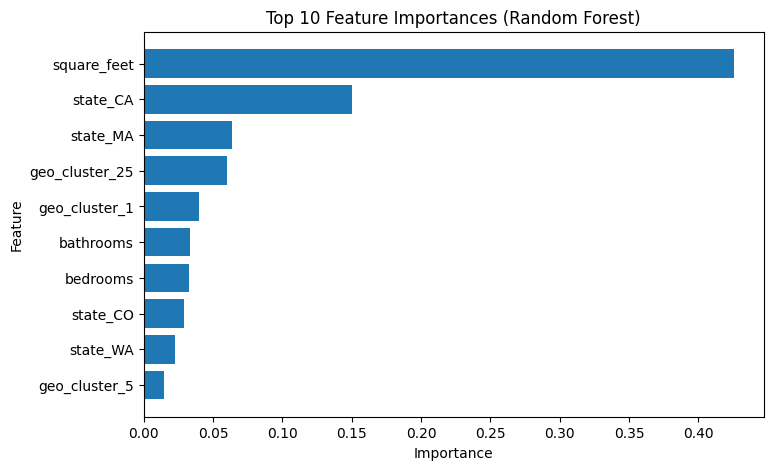

In [62]:
import matplotlib.pyplot as plt

top10 = feature_importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

The feature importance results show that square footage is the most influential factor in determining rental prices, indicating that property size is the primary driver of value.

Geographic variables, including state and geo-cluster features, also have strong importance. This confirms that location plays a critical role, and that geo-cluster features capture local market differences beyond state-level information.

In contrast, structural variables such as bedrooms and bathrooms have relatively smaller contributions, suggesting that size and location dominate the pricing mechanism.

## Residual Analysis

### Residual Histogram

In [63]:
# Forecast
y_pred = final_model.predict(X_test)

# residual
residuals = y_test - y_pred

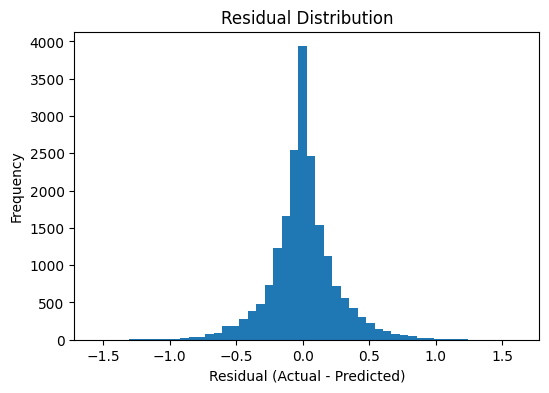

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=50)

plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")

plt.show()

### Predicted vs Actual

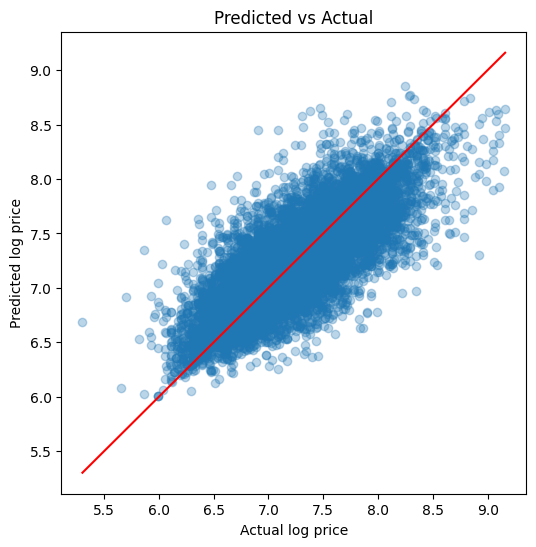

In [65]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.3)

# 理想线
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')

plt.xlabel("Actual log price")
plt.ylabel("Predicted log price")
plt.title("Predicted vs Actual")

plt.show()

### Residual vs Predicted

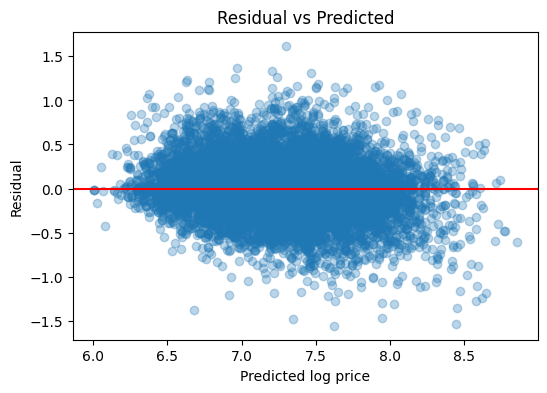

In [66]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, residuals, alpha=0.3)

plt.axhline(0, color='red')

plt.xlabel("Predicted log price")
plt.ylabel("Residual")
plt.title("Residual vs Predicted")

plt.show()

### Error by Price Range

In [67]:
# Create price segments based on actual log price
residual_df = pd.DataFrame({
    "actual_log_price": y_test,
    "predicted_log_price": y_pred
}, index=y_test.index)

residual_df["residual"] = residual_df["actual_log_price"] - residual_df["predicted_log_price"]
residual_df["abs_error"] = residual_df["residual"].abs()
residual_df["sq_error"] = residual_df["residual"] ** 2

# Split into 3 groups by actual price
residual_df["price_segment"] = pd.qcut(
    residual_df["actual_log_price"],
    q=3,
    labels=["Low", "Mid", "High"]
)

# Summarize error by segment
error_by_segment = residual_df.groupby("price_segment", observed=False).agg(
    count=("residual", "size"),
    MAE=("abs_error", "mean"),
    RMSE=("sq_error", lambda x: np.sqrt(np.mean(x)))
).reset_index()

display(error_by_segment.round(4))

,price_segment,count,MAE,RMSE
0,Low,6634,0.1706,0.2509
1,Mid,6575,0.1377,0.1989
2,High,6603,0.2079,0.2933


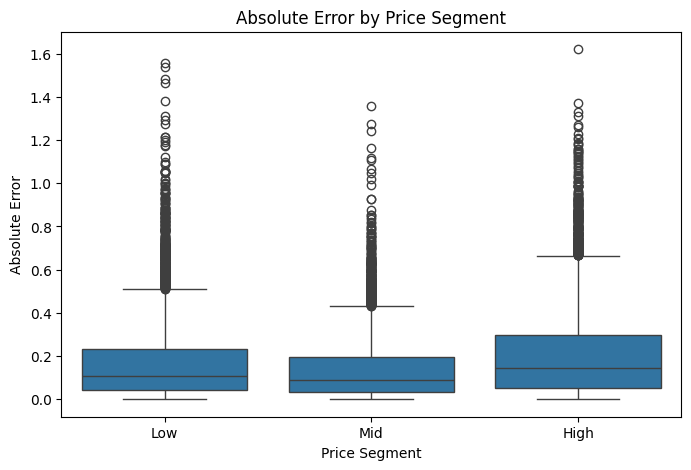

In [68]:
plt.figure(figsize=(8,5))
sns.boxplot(data=residual_df, x="price_segment", y="abs_error")
plt.title("Absolute Error by Price Segment")
plt.xlabel("Price Segment")
plt.ylabel("Absolute Error")
plt.show()

### Residual Analysis

The residual distribution is broadly centered around zero, suggesting that the final Random Forest combined model does not show strong overall systematic bias. However, the distribution still has visible tails, indicating that some listings remain difficult to predict accurately.

The predicted-versus-actual plot shows a clear positive relationship, and many predictions fall reasonably close to the diagonal reference line. This suggests that the model captures the general pricing pattern well. At the same time, dispersion becomes wider in the higher-price range, which indicates that expensive listings are harder to estimate precisely.

The residual-versus-predicted plot further shows that most errors remain concentrated around zero, but the spread increases somewhat as predicted log price rises. This pattern is consistent with mild heteroskedasticity, meaning that prediction uncertainty is larger for higher-priced rentals.

To further examine where the model performs less reliably, the test set was divided into low-, mid-, and high-price segments. The results show that the mid-price segment has the lowest error (MAE = 0.3142, RMSE = 0.3960), while both the low-price and high-price segments have substantially larger errors. The high-price segment has the largest overall error (MAE = 0.5496, RMSE = 0.6733), and the low-price segment also shows elevated error (MAE = 0.5071, RMSE = 0.6256). This suggests that the model is most reliable in the middle of the market and less stable at both ends, where pricing may be influenced by more unusual local conditions, listing quality differences, or segment-specific market behavior.

Overall, the final model performs well for general fair-value estimation, but prediction uncertainty is lower in the mid-market segment and higher for both lower-priced and higher-priced listings. This means the model can be used as a useful pricing benchmark, but extra caution is needed when interpreting recommendations for properties at the lower and upper ends of the market.

## Robustness Check

In [69]:
seeds = [0, 42, 100]

robust_results = []

for seed in seeds:
    train_idx, test_idx = train_test_split(
        df_model.index,
        test_size=0.2,
        random_state=seed
    )
    
    # final model: Random Forest + combined + k=30
    X_train, X_test, y_train, y_test = build_train_test_features(
        df_model,
        train_idx,
        test_idx,
        setting="combined",
        k=30
    )
    
    model = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
    
    mae, rmse = evaluate_model(model, X_train, X_test, y_train, y_test)
    
    robust_results.append({
        "seed": seed,
        "MAE": mae,
        "RMSE": rmse
    })

robust_df = pd.DataFrame(robust_results)
display(robust_df.round(4))

ValueError: too many values to unpack (expected 2)

### Robustness Check

To ensure that the model performance is not dependent on a specific train-test split, the final model was evaluated using different random seeds.

The results show that the MAE and RMSE remain highly stable across different splits, with only minor variations. For example, MAE ranges from approximately 0.168 to 0.170, and RMSE ranges from approximately 0.246 to 0.249.

This indicates that the performance of the Random Forest combined model is robust and not driven by random variation in the data split.

# 8. Price Band Classification

##  8.1 Test-set classification

Raw band dataset shape: (99057, 7)
Band classification dataset shape: 99057 rows
Train OOF sigma: 0.2546544726085329

=== Test Set Band Distribution ===
price_band
Fair       15272
Premium     2356
Deal        2184
Name: count, dtype: int64

=== Test Set Band Proportion ===
price_band
Fair       0.7708
Premium    0.1189
Deal       0.1102
Name: proportion, dtype: float64


,actual_log_price,predicted_log_price,residual,price_band,actual_price,predicted_price,price_gap,gap_pct
92255,7.099202,6.895323,0.203879,Fair,1211.0,987.644581,223.355419,0.226150
67981,7.919720,7.335662,0.584058,Premium,2751.0,1534.042588,1216.957412,0.793301
11163,7.616284,7.630257,-0.013974,Fair,2031.0,2059.579784,-28.579784,-0.013877
89309,8.006701,7.141726,0.864975,Premium,3001.0,1263.607201,1737.392799,1.374947
86083,7.888335,8.045436,-0.157101,Fair,2666.0,3119.523505,-453.523505,-0.145382



=== Train OOF Band Distribution ===
price_band
Fair       59924
Premium     9916
Deal        9405
Name: count, dtype: int64

=== Train OOF Band Proportion ===
price_band
Fair       0.7562
Premium    0.1251
Deal       0.1187
Name: proportion, dtype: float64


,actual_log_price,predicted_log_price,residual,price_band,actual_price,predicted_price,price_gap,gap_pct
30401,7.303843,7.400521,-0.096678,Fair,1486.0,1636.837655,-150.837655,-0.092152
82004,7.307202,7.165612,0.141591,Fair,1491.0,1294.152964,196.847036,0.152105
544,7.467942,7.335282,0.132660,Fair,1751.0,1533.459980,217.540020,0.141862
87455,7.061334,6.985092,0.076242,Fair,1166.0,1080.405856,85.594144,0.079224
33525,7.074117,7.129935,-0.055818,Fair,1181.0,1248.795428,-67.795428,-0.054289


test_band_df columns: ['actual_log_price', 'predicted_log_price', 'residual', 'price_band', 'actual_price', 'predicted_price', 'price_gap', 'gap_pct']
train_oof_df columns: ['actual_log_price', 'predicted_log_price', 'residual', 'price_band', 'actual_price', 'predicted_price', 'price_gap', 'gap_pct']

=== Test Set Price Summary by Band ===


,count,mean,std,min,25%,50%,75%,max
price_band,,,,,,,,
Deal,2184.0,1123.73,496.92,201.0,781.00,1001.0,1351.0,4151.0
Fair,15272.0,1442.06,596.12,351.0,1020.00,1330.0,1702.0,6901.0
Premium,2356.0,2332.01,1166.35,676.0,1530.75,2079.0,2801.0,9501.0



=== Train OOF Price Summary by Band ===


,count,mean,std,min,25%,50%,75%,max
price_band,,,,,,,,
Deal,9405.0,1133.94,503.10,101.0,777.00,1011.0,1376.0,5501.0
Fair,59924.0,1443.30,610.17,366.0,1021.00,1329.0,1701.0,7996.0
Premium,9916.0,2327.86,1140.27,526.0,1548.75,2087.0,2801.0,9976.0



=== Train OOF Gap Percentage Summary by Band ===


,count,mean,std,min,25%,50%,75%,max
price_band,,,,,,,,
Deal,9405.0,-0.3412,0.0995,-0.9055,-0.3955,-0.3143,-0.2624,-0.2248
Fair,59924.0,0.0037,0.1178,-0.2248,-0.0794,-0.0032,0.0778,0.2900
Premium,9916.0,0.5895,0.3467,0.2901,0.3673,0.4849,0.6872,8.7740


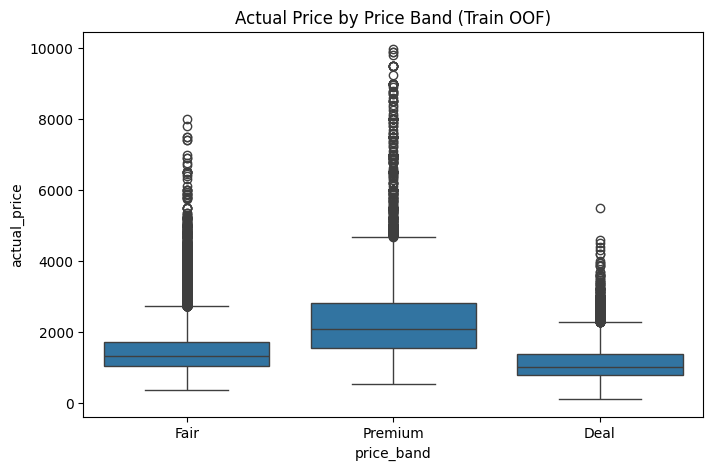

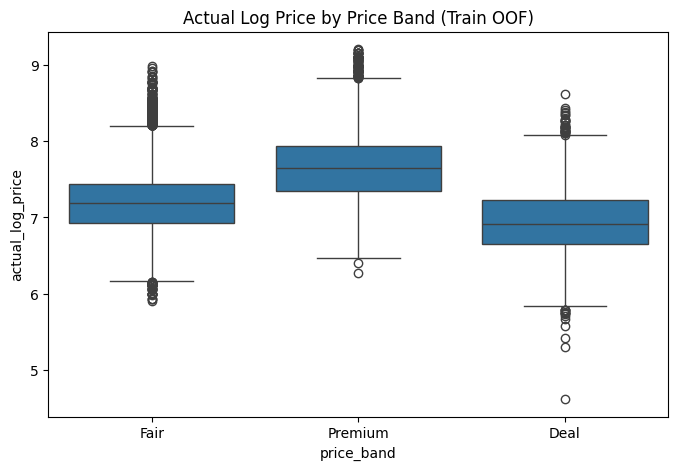

In [ ]:
# =========================================
# Price Band Classification
# Final model: Random Forest + state + geo_cluster (k=30)
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.base import clone


# =========================================
# 1. Prepare raw data for final best model
# =========================================
df_band_raw = df[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "latitude",
    "longitude",
    "log_price"
]].dropna().copy()

print("Raw band dataset shape:", df_band_raw.shape)


# =========================================
# 2. Classification rule
# =========================================
def classify_band(residual, sigma):
    if residual < -sigma:
        return "Deal"
    elif residual > sigma:
        return "Premium"
    else:
        return "Fair"


# =========================================
# 3. Train/test split FIRST
#    Then fit cluster only on train
# =========================================
train_idx_band, test_idx_band = train_test_split(
    df_band_raw.index,
    test_size=0.2,
    random_state=42
)

train_band_raw = df_band_raw.loc[train_idx_band].copy()
test_band_raw = df_band_raw.loc[test_idx_band].copy()

k_best = 30
kmeans_band = KMeans(n_clusters=k_best, random_state=42)
kmeans_band.fit(train_band_raw[["latitude", "longitude"]])

train_band_raw["geo_cluster"] = kmeans_band.predict(train_band_raw[["latitude", "longitude"]])
test_band_raw["geo_cluster"] = kmeans_band.predict(test_band_raw[["latitude", "longitude"]])


# =========================================
# 4. Build combined features
# =========================================
train_band = train_band_raw[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "geo_cluster",
    "log_price"
]].copy()

test_band = test_band_raw[[
    "square_feet",
    "bedrooms",
    "bathrooms",
    "state",
    "geo_cluster",
    "log_price"
]].copy()

X_train_band = pd.get_dummies(
    train_band.drop(columns=["log_price"]),
    columns=["state", "geo_cluster"],
    drop_first=True
)

X_test_band = pd.get_dummies(
    test_band.drop(columns=["log_price"]),
    columns=["state", "geo_cluster"],
    drop_first=True
)

# align columns
X_train_band, X_test_band = X_train_band.align(
    X_test_band, join="left", axis=1, fill_value=0
)

y_train_band = train_band["log_price"]
y_test_band = test_band["log_price"]

print("Band classification dataset shape:", X_train_band.shape[0] + X_test_band.shape[0], "rows")


# =========================================
# 5. Define final best model
# =========================================
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)


# =========================================
# 6. Build TRAIN OOF predictions
#    Use training OOF residual std as fixed sigma
# =========================================
kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof_pred = np.zeros(len(X_train_band))

for fold_train_idx, fold_valid_idx in kf.split(X_train_band):
    X_fold_train = X_train_band.iloc[fold_train_idx]
    X_fold_valid = X_train_band.iloc[fold_valid_idx]
    y_fold_train = y_train_band.iloc[fold_train_idx]

    fold_model = clone(final_model)
    fold_model.fit(X_fold_train, y_fold_train)
    train_oof_pred[fold_valid_idx] = fold_model.predict(X_fold_valid)

train_oof_df = pd.DataFrame({
    "actual_log_price": y_train_band,
    "predicted_log_price": train_oof_pred
}, index=y_train_band.index)

train_oof_df["residual"] = (
    train_oof_df["actual_log_price"] - train_oof_df["predicted_log_price"]
)

sigma_train = train_oof_df["residual"].std()
print("Train OOF sigma:", sigma_train)


# =========================================
# 7. Fit on full training set, predict on test set
# =========================================
final_model.fit(X_train_band, y_train_band)
y_test_pred = final_model.predict(X_test_band)

test_band_df = pd.DataFrame({
    "actual_log_price": y_test_band,
    "predicted_log_price": y_test_pred
}, index=y_test_band.index)

test_band_df["residual"] = (
    test_band_df["actual_log_price"] - test_band_df["predicted_log_price"]
)

# fixed sigma from TRAIN OOF
test_band_df["price_band"] = test_band_df["residual"].apply(
    lambda x: classify_band(x, sigma_train)
)

test_band_df["actual_price"] = np.exp(test_band_df["actual_log_price"])
test_band_df["predicted_price"] = np.exp(test_band_df["predicted_log_price"])
test_band_df["price_gap"] = (
    test_band_df["actual_price"] - test_band_df["predicted_price"]
)
test_band_df["gap_pct"] = (
    test_band_df["price_gap"] / test_band_df["predicted_price"]
)

print("\n=== Test Set Band Distribution ===")
print(test_band_df["price_band"].value_counts())
print("\n=== Test Set Band Proportion ===")
print(test_band_df["price_band"].value_counts(normalize=True).round(4))

display(test_band_df.head())


# =========================================
# 8. OOF classification for training set
#    Also use the same sigma_train
# =========================================
train_oof_df["price_band"] = train_oof_df["residual"].apply(
    lambda x: classify_band(x, sigma_train)
)

train_oof_df["actual_price"] = np.exp(train_oof_df["actual_log_price"])
train_oof_df["predicted_price"] = np.exp(train_oof_df["predicted_log_price"])
train_oof_df["price_gap"] = (
    train_oof_df["actual_price"] - train_oof_df["predicted_price"]
)
train_oof_df["gap_pct"] = (
    train_oof_df["price_gap"] / train_oof_df["predicted_price"]
)

print("\n=== Train OOF Band Distribution ===")
print(train_oof_df["price_band"].value_counts())
print("\n=== Train OOF Band Proportion ===")
print(train_oof_df["price_band"].value_counts(normalize=True).round(4))

display(train_oof_df.head())

# safety check: recreate price_band if missing
if "price_band" not in test_band_df.columns:
    test_band_df["price_band"] = test_band_df["residual"].apply(
        lambda x: classify_band(x, sigma_train)
    )

if "price_band" not in train_oof_df.columns:
    train_oof_df["price_band"] = train_oof_df["residual"].apply(
        lambda x: classify_band(x, sigma_train)
    )

print("test_band_df columns:", test_band_df.columns.tolist())
print("train_oof_df columns:", train_oof_df.columns.tolist())

# =========================================
# 9. Summary by band
# =========================================
print("\n=== Test Set Price Summary by Band ===")
display(test_band_df.groupby("price_band")["actual_price"].describe().round(2))

print("\n=== Train OOF Price Summary by Band ===")
display(train_oof_df.groupby("price_band")["actual_price"].describe().round(2))

print("\n=== Train OOF Gap Percentage Summary by Band ===")
display(train_oof_df.groupby("price_band")["gap_pct"].describe().round(4))


# =========================================
# 10. Visualization
# =========================================
plt.figure(figsize=(8, 5))
sns.boxplot(data=train_oof_df, x="price_band", y="actual_price")
plt.title("Actual Price by Price Band (Train OOF)")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=train_oof_df, x="price_band", y="actual_log_price")
plt.title("Actual Log Price by Price Band (Train OOF)")
plt.show()

The price band classification results show a consistent and meaningful pattern.

Across both the test set and the out-of-fold (OOF) predictions, approximately 76–77% of listings are classified as Fair, while around 11–12% fall into Deal and Premium categories. The consistency between test and OOF distributions suggests that the classification is stable and not driven by random data splits.

The average price differs significantly across bands. Deal listings have the lowest average price, followed by Fair listings, while Premium listings have the highest. This confirms that the classification captures meaningful price differences.

Furthermore, the gap percentage analysis shows that Deal listings are on average around 33% below the model’s predicted price, while Premium listings are approximately 58% above it. This indicates that the classification is economically meaningful and can be used to identify underpriced and overpriced listings.

Overall, the classification framework successfully translates regression predictions into a practical decision tool for detecting pricing inefficiencies in the rental market.


# Final Conclusion

This project developed a fair-value rent estimation framework using machine learning models and geographic feature engineering.

The results show that the Random Forest combined model, which integrates both state-level information and geo-cluster features, achieves the best predictive performance. This demonstrates that local spatial structures provide additional value beyond traditional location variables.

Feature importance analysis indicates that both structural characteristics (such as square footage) and geographic factors play key roles in determining rental prices. Residual analysis further confirms that the model performs well overall, although prediction uncertainty is higher for high-priced listings.

Finally, the price band classification successfully translates model predictions into a practical decision tool, enabling the identification of underpriced and overpriced listings.

Overall, this study shows that combining structural and spatial features can improve rental price estimation and provide actionable insights for market analysis.